# 🧠 Hierarchical Multimodal Transformer

Custom transformer architecture designed for energy prediction from MRI <br>
sequence data with interpretable attention mechanisms.

---

## 🎯 Overview
- 🔀 **Multimodal Processing:** Dedicated processing channels for Numerical <br>
and Text+Categorical data
- 🏗️ **Hierarchical Design:** Progressive dimensionality reduction through <br>
bottleneck architecture for improved generalization
- 🔗 **Cross-Modal Interaction:** Channels exchange information and learn <br>
joint representations during processing
- 🧩 **Unified Prediction:** Final representations from both channels are <br>
combined for energy consumption prediction
- 🧐 **Interpretable Analysis:** Direct access to attention weights enables <br>
comprehensive feature importance evaluation

---

## 📋 Implementation

**📄 transformer.ipynb**

## 🏗️ Architecture Details
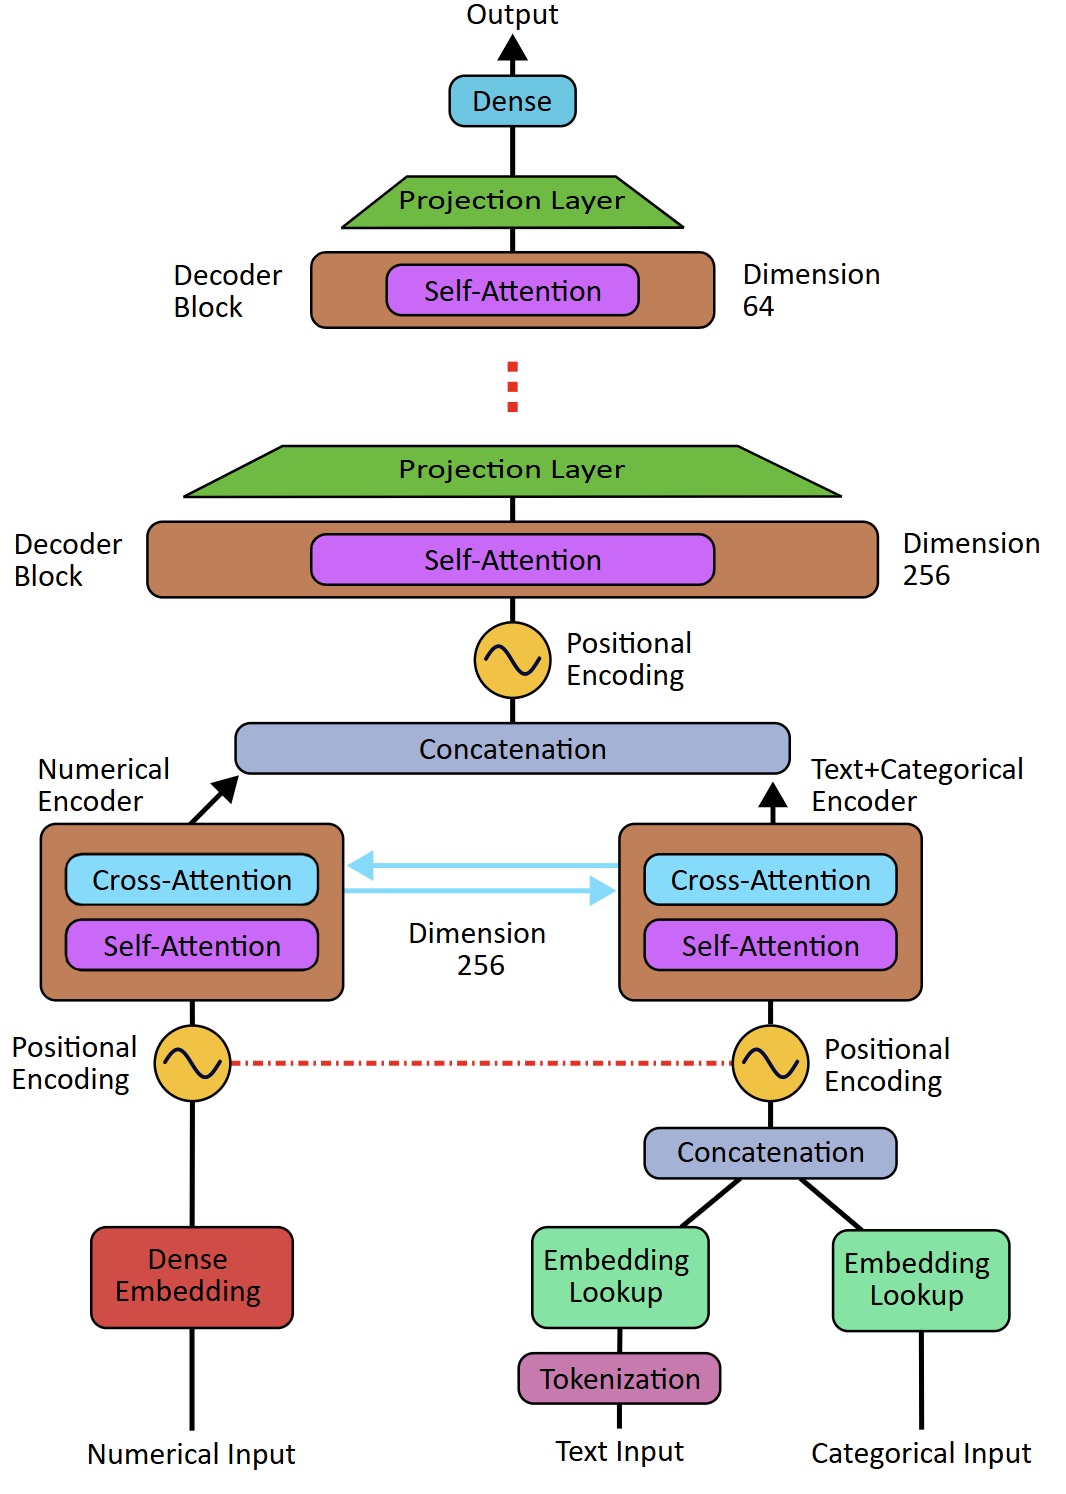

### 🛤️ **Dual-Channel Processing**
- **🔢 Numerical Channel:** Input Projection Layer (Dense Layer) processes <br>
numerical MRI parameters
- **🔤 Text+Categorical Channel:** Embedding Layer (Look-up Matrix) handles <br>
textual and categorical features

### 🧠 **Hierarchical Encoder-Decoder Structure**
- **🔄 Encoder Blocks:** Utilize both self-attention and cross-attention <br>
mechanisms for intra- and inter-modal learning
- **🎯 Decoder Blocks:** Use only self-attention mechanisms to process <br>
concatenated representations
- **📉 Progressive Reduction:** Model dimensions are systematically reduced <br>
across Decoder blocks
- **➡️ Projection Layers:** Dense layers between blocks enable controlled <br>
dimensionality reduction
- **🔗 Channel Fusion:** Encoded latent sequences from both channels are <br>
concatenated for unified representation

### 🔀 **Cross-Attention in Encoder Blocks**
- 🔄 **Two-Stage Processing:** Encoder blocks are split into two sequential <br>
stages for proper cross-modal interaction
- 1️⃣ **Stage 1 - Self-Attention:** Each modality (numerical and text+categorical) <br>
first processes its own features independently through self-attention layers
- 2️⃣ **Stage 2 - Cross-Attention:** After self-attention, both modalities exchange <br>
information through cross-attention mechanisms
- ⚙️ **Why This Split?** Cross-attention requires the refined representations <br>
from self-attention as input—each channel must first understand its own features <br>
before learning relationships across modalities
- 🔗 **Information Flow:** Numerical features attend to text+categorical features, <br>
and vice versa, enabling bidirectional cross-modal learning

### 🎯 **Output Generation**
- **🎯 Dense Regression Layer:** A fully connected layer maps the flattened <br>
features to energy consumption predictions
- **📊 Attention Export:** All attention weights are directly accessible for <br>
comprehensive interpretability analysis

This architecture combines the strengths of multimodal processing with <br>
hierarchical representation learning, enabling both accurate predictions and <br>
meaningful insights into MRI parameter relationships.

# 📁 Additional Folders
Several additional folders are automatically created to organize and store <br>
information during and after the Hierachical Transformer training.

## 📁 runs
-  📊Folder to store TensorBoard summary writer files for training visualization

## 📁 model_output
- Folder to store the certain items:
  - 🏋️ Saves the model parameters via the state dictionary for reuse and reproducibility
  - 🧠 Stores compressed and averaged attention values for interpretability and analysis
  - 📈 Saves model predictions and true targets for further analysis and reproducibility.
  - 📉 Stores the loss during the CV and training of the full data set
  - ⚙️ Saves the model of the model configuration / hyperparameters

> Output folders are further divided up by regression for energy and power

---
- 🧩 The class used to create the dataset can be found in:
  `Deep Learning/Pipeline-V2/Hierachical Transformer/Dataset Tokenization/Dataset Tokenization utils_opt`
- 📉 The class used for tracking the training and validation loss can be found in:
  `Global DL_utils_opt/loss_dataclass.py`



In [ ]:
import os
import sys
import io

from PIL import Image
import pandas as pd
import polars as pl
import plotly.graph_objects as go

import datetime
from tqdm import tqdm
import math
import numpy as np
import pickle

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import DataLoader, Dataset, random_split, TensorDataset
from tokenizers import Tokenizer


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold

import random
from typing import  Tuple, Dict, List, Optional

# Set the random seed for reproducibility for the DataLoaders and any other random operations
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Create random number generators for PyTorch and NumPy to ensure reproducibility
GEN_TORCH = torch.Generator()
GEN_TORCH.manual_seed(RANDOM_SEED)
GEN_NP = np.random.default_rng(RANDOM_SEED)

# Check if the GPU is available and set the device accordingly
if torch.cuda.is_available():
    print("✅ Using GPU:", torch.cuda.get_device_name(0))

# Get the current working directory
CWD = os.getcwd()

# Define the path to the local utils directory
LOCA_UTILS_DIR = os.path.normpath(os.path.join(CWD, "..", "Dataset Tokenization", "Dataset Tokenization utils_opt"))
# Define the path to the global utils directory
GLOBAL_UTILS_DIR = os.path.normpath(
    os.path.join(CWD, "..", "..",  "..",  "Global utils_opt")
)
# Define the path to the global DL utils directory
GLOBAL_DL_UTILS_DIR = os.path.normpath(
    os.path.join(CWD, "..", "..",  "..", "Global DL_utils_opt")
)

# Append this directory to the system path
sys.path.append(LOCA_UTILS_DIR)
sys.path.append(GLOBAL_UTILS_DIR)
sys.path.append(GLOBAL_DL_UTILS_DIR)


from global_utils import *
from dataset_tokenization_utils import *
from loss_dataclass_plotting import *

# Enable autoreload and black formatting in Jupyter notebooks
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

✅ Found style_sheet_matplotlib.mplstyle at: /home/raraabf1/PhD/MRI_data_analysis/Stylesheets/style_sheet_matplotlib.mplstyle
✅ Found style_sheet_plotly.json at: /home/raraabf1/PhD/MRI_data_analysis/Stylesheets/style_sheet_plotly.json


## 📝 Summary Writer

A TensorBoard `SummaryWriter` is used to log key metrics and information <br>
during training and evaluation:

- 📊 Tracks batch and epoch losses for monitoring model performance.
- 🧠 Logs gradients for deeper insight into model learning.
- 🗂️ Records model architecture and parameter counts for reproducibility.
- 📝 Adds text notes to document important steps and events throughout the run.

In [ ]:
# Define the mode either "energy" or "power". This will determine which label 
# column to use and how to interpret the data.
MODE = "power"

print(f"🚀 Running in {MODE} mode.")

# Set this flag to True if you want to test the transformer model with artifical
# data.
TEST_TRANSFORMER = False

In [4]:
# Introduce a summary writer to log the loss
CURRENT_TIME = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")

# Define the runs directory path with the mode as a suffix
RUNS_DIR = os.path.normpath(os.path.join(CWD, f"runs_{MODE}"))
# Create the runs directory if it doesn't exist
os.makedirs(RUNS_DIR, exist_ok=True)


# Introduce a summary writer to log the loss with a filename suffix
WRITER = SummaryWriter(os.path.join(RUNS_DIR, CURRENT_TIME))

## 📐 Architecture of the Model + Encoder/Decoder Block Dimensions

| Layer/Step                | Input Shape                        | Output Shape                       |
|---------------------------|------------------------------------|------------------------------------|
| **Input Data**            | `(batch_size, seq_len)`            |                                    |
| **Input Projection**      | `(batch_size, seq_len, 1)`         | `(batch_size, seq_len, d_model[0])`|
| **Embedding Layer**       | `(batch_size, seq_len)`            | `(batch_size, seq_len, d_model[0])`|
| **Positional Encoding**   | `(batch_size, seq_len, d_model)`   | `(batch_size, seq_len, d_model)`   |
| **Multihead Attention**   | `(batch_size, seq_len, d_model)`   |                                    |
| - Split Heads             |                                    | `(batch_size, num_heads, seq_len, d_head)` |
| - Attention Weights       |                                    | `(batch_size, num_heads, seq_len, seq_len)` |
| - Output (per head)       |                                    | `(batch_size, num_heads, seq_len, d_head)` |
| - Concat Heads            |                                    | `(batch_size, seq_len, d_model)`   |
| **FeedForward**           | `(batch_size, seq_len, d_model)`   | `(batch_size, seq_len, d_ff)`      |
|                           |                                    | `(batch_size, seq_len, d_model)`   |
| **Projection Layer**      | `(batch_size, seq_len, d_model[i])`| `(batch_size, seq_len, d_model[i+1])` |

<br>

- Shapes are consistent with the code and standard Transformer architectures.

In [5]:
class EmbeddingLayer(nn.Module):
    """
    Look-up matrix for the embeddings of the tokens. This layer is used to
    convert token indices into dense vectors of fixed size.

    Parameters:
    - vocab_size (int): The size of the vocabulary, i.e., the number of unique tokens.
    - embedding_dim (int): The size of the embedding vectors.
    """

    def __init__(self, vocab_size: int, embedding_dim: int):
        super(EmbeddingLayer, self).__init__()

        # Create the embedding layer with the specified vocabulary size and embedding dimension
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the embedding layer.

        Parameters:
        - x (torch.Tensor): Input tensor containing token indices of shape
            (batch_size, sequence_length).
        Returns:
        - torch.Tensor: Output tensor containing the corresponding embeddings of
            shape (batch_size, sequence_length, embedding_dim).
        """

        # Dimensions:
        # Batch_size, sequence_length -> Batch_size, sequence_length, embedding_dim
        x, embedding = self.embedding(x), self.embedding.weight

        return x, embedding

In [6]:
class PositionalEncoding(nn.Module):
    """
    Use a cosine and sine positional encoding to encode the position of each
    token in the input sequence. This is used to give the model a sense of
    the order of the tokens in the sequence.

    Paramters:
    - d_model (int): The dimension of the model.
    - max_seq_len (int): The maximum length of the input sequence
    - start_idx (int): The starting index for the positional encoding, default is 0.
    """

    def __init__(
        self,
        d_model: int,
        max_seq_len: int,
        start_idx: int = 0,
    ):

        super(PositionalEncoding, self).__init__()

        # Initialize the positional__encoding tensors, which is a 2D tensor of shape (max_seq_len, d_model)
        positional_encoding = torch.zeros(max_seq_len, d_model)
        # Create a position tensors, use unsqueeze to change the dimension from
        # (max_seq_len) to (max_seq_len, 1)
        position = torch.arange(
            start_idx, max_seq_len + start_idx, dtype=torch.float
        ).unsqueeze(1)
        division_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # Calculate the positional encoding using sine and cosine functions
        # For the sine term start at 0 and step by 2, for the cosine term start at 1 and step by 2
        positional_encoding[:, 0::2] = torch.sin(position * division_term)
        positional_encoding[:, 1::2] = torch.cos(position * division_term)

        # Unsqueeze the positional encoding tensor to add a batch dimension
        # This changes the shape from (max_seq_len, d_model) to (1, max_seq_len, d_model)
        positional_encoding = positional_encoding.unsqueeze(0)

        # Register the positional encoding tensor as a buffer, so that it is not a
        # parameter of the model. The register_buffer methods also converts the
        # local variable to a attribute of the class
        self.register_buffer("positional_encoding", positional_encoding)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the positional encoding layer.

        Parameters:
        - x (torch.Tensor): The input tensor of shape (batch_size, seq_len, d_model)

        Returns:
        - torch.Tensor: The input tensor with positional encoding added of shape
            (batch_size, seq_len, d_model)
        """

        # Add the positional encoding to the input tensor
        # Dimensions:
        # Batch_size, sequence_length, d_model -> Batch_size, sequence_length + positional_encoding, d_model
        return x + self.positional_encoding[:, : x.size(1), :]

In [7]:
class MultiHeadAttention(nn.Module):
    """
    Multi-head attention layer that applies the scaled dot-product attention mechanism
    across multiple heads. This allows the model to jointly attend to information
    from different representation subspaces.

    Parameters:
    - d_model (int): The dimension of the model, i.e., the size of the input and output vectors.
    - num_heads (int): The number of attention heads to use in the multi-head attention mechanism.
    """

    def __init__(self, d_model: int, num_heads: int):

        super(MultiHeadAttention, self).__init__()

        # Ensure that the d_model is divisible by num_heads
        if d_model % num_heads != 0:
            raise ValueError(
                "Dimension of the model (d_model) must be divisible by the number of heads (num_heads)."
            )

        # Get the dimensions
        self.d_model = d_model
        # Set the number of heads
        self.num_heads = num_heads
        # Dimension of the Key, Query and Value vectors
        self.d_heads = d_model // num_heads

        # Feed Forward layers for the Query, Key and Values
        self.W_Query = nn.Linear(d_model, d_model)
        self.W_Key = nn.Linear(d_model, d_model)
        self.W_Values = nn.Linear(d_model, d_model)

        # Output layer to combine the heads
        self.W_Output = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(
        self,
        Query: torch.Tensor,
        Key: torch.Tensor,
        Value: torch.Tensor,
        mask: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Scaled dot-product attention mechanism. This function computes the attention scores
        by taking the dot product of the Query and Key vectors, scaling them by the square root
        of the dimension of the heads, and applying a softmax function to obtain the attention weights.

        Parameters:
        - Query (torch.Tensor): The query tensor of shape (batch_size, num_heads, seq_len, d_heads).
        - Key (torch.Tensor): The key tensor of shape (batch_size, num_heads, seq_len, d_heads).
        - Value (torch.Tensor): The value tensor of shape (batch_size, num_heads, seq_len, d_heads).
        - mask (torch.Tensor, optional): An optional mask tensor to apply to the attention scores.

        Returns:
        - output (torch.Tensor): The output tensor of shape (batch_size, num_heads, seq_len, d_heads).
        - attn_weights (torch.Tensor): The attention weights of shape (batch_size, num_heads, seq_len, seq_len).

        """

        # Calculate the attention scores by taking the dot product of the Query and
        # Key vectors. The Dot product is performed along the last two dimensions
        # of the Query and Key tensors.
        # Dimensions:
        # Query: (batch_size, num_heads, seq_len, d_heads)
        # Key: (batch_size, num_heads, seq_len, d_heads)
        # Attention scores: (batch_size, num_heads, seq_len, seq_len)
        attn_scores = torch.matmul(Query, Key.transpose(-2, -1)) / math.sqrt(
            self.d_heads
        )

        # Apply the mask if provided
        if mask is not None:
            # To allow the correct broadcasting, get the max sequence lengths
            # of the Query. Since depending on self or cross attention these
            # can be different.
            max_seq_len_q = Query.size(2)

            # Expand the mask to match the shape of the attention scores:
            # (batch_size, seq_len_v) -> (batch_size, 1, 1, seq_len_v)
            mask = mask.unsqueeze(1).unsqueeze(2)
            # Expand the mask to (batch_size, num_heads, seq_len_q, seq_len_v)
            mask = mask.expand(-1, self.num_heads, max_seq_len_q, -1)

            # If the mask is 0 set the corresponding attention scores to -inf
            attn_scores = attn_scores.masked_fill(mask == 0, float("-inf"))

        # Apply the softmax function to the attention scores to get the attention weights
        attn_weights = torch.softmax(attn_scores, dim=-1)

        # Multiply the attention weights with the Value vectors to get the output.
        # The Dot product is performed along the last two dimensions of the
        # attention weights and Value tensors.
        # Dimensions:
        # attn_weights: (batch_size, num_heads, seq_len, seq_len)
        # Value: (batch_size, num_heads, seq_len, d_heads)
        # Output: (batch_size, num_heads, seq_len, d_heads)
        output = torch.matmul(attn_weights, Value)
        return output, attn_weights

    def split_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Split the input tensor into multiple heads. This is done by reshaping the input tensor
        to have an additional dimension for the number of heads. The input tensor is expected
        to have the shape (batch_size, seq_len, d_model), where d_model is the dimension of the model.

        Parameters:
        - x (torch.Tensor): The input tensor of shape (batch_size, seq_len, d_model).

        Returns:
        - torch.Tensor: The reshaped tensor of shape (batch_size, seq_len, num_heads, d_heads),
          where num_heads is the number of attention heads and d_heads is the dimension of each head.
        """

        # Input x is of shape (batch_size, seq_len, d_model)
        batch_size, seq_len, d_model = x.size()
        # Reshape x to (batch_size, seq_len, num_heads, d_heads)
        x = x.view(batch_size, seq_len, self.num_heads, self.d_heads)
        # Transpose the dimensions to (batch_size, num_heads, seq_len, d_heads)
        x = x.transpose(1, 2)

        return x

    def combine_heads(self, x: torch.Tensor) -> torch.Tensor:
        """
        Combine the multiple heads back into a single tensor. This is done by
        reshaping the input tensor. The input tensor is expected to have the shape
        (batch_size, num_heads, seq_len, d_heads), where num_heads is the number of
        attention heads and d_heads is the dimension of each head.

        Parameters:
        - x (torch.Tensor): The input tensor of shape (batch_size, num_heads, seq_len, d_heads).

        Returns:
        - torch.Tensor: The reshaped tensor of shape (batch_size, seq_len, d_model),
          where d_model is the dimension of the model.
        """

        # Input x is of shape (batch_size, num_heads, seq_len, d_heads)
        batch_size, num_heads, seq_len, d_heads = x.size()

        # The output should be of shape (batch_size, seq_len, d_model
        # So transpose num_heads and seq_len and the combine the heads
        x = x.transpose(1, 2).contiguous()
        x = x.view(batch_size, seq_len, self.d_model)
        return x

    def forward(
        self,
        Query: torch.Tensor,
        Key: torch.Tensor,
        Value: torch.Tensor,
        mask: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass of the multi-head attention layer.

        Parameters:
        - Query (torch.Tensor): The query tensor of shape (batch_size, seq_len, d_model).
        - Key (torch.Tensor): The key tensor of shape (batch_size, seq_len, d_model).
        - Value (torch.Tensor): The value tensor of shape (batch_size, seq_len, d_model).
        - mask (torch.Tensor): An optional mask tensor to apply to the attention scores.

        Returns:
        - output (torch.Tensor): The output tensor of shape (batch_size, seq_len, d_model).
        - attn_weights (torch.Tensor): The attention weights of shape (batch_size, num_heads, seq_len, seq_len).
        """

        # Apply the linear transformations to the Query, Key and Value tensors
        # Dimensions:
        # Query: (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        # Key: (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        # Value: (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        Query = self.W_Query(Query)
        Key = self.W_Key(Key)
        Value = self.W_Values(Value)

        # Split the heads
        # Dimensions:
        # Query: (batch_size, seq_len, d_model) -> (batch_size, num_heads, seq_len, d_heads)
        # Key: (batch_size, seq_len, d_model) -> (batch_size, num_heads, seq_len, d_heads)
        # Value: (batch_size, seq_len, d_model) -> (batch_size, num_heads, seq_len, d_heads)
        Query = self.split_heads(Query)
        Key = self.split_heads(Key)
        Value = self.split_heads(Value)

        # Apply the scaled dot product attention
        # Dimensions:
        # Query: (batch_size, num_heads, seq_len, d_heads)
        # Key: (batch_size, num_heads, seq_len, d_heads)
        # Value: (batch_size, num_heads, seq_len, d_heads)
        output, attn_weights = self.scaled_dot_product_attention(
            Query, Key, Value, mask
        )

        # Combine the heads
        # Dimensions:
        # (batch_size, num_heads, seq_len, d_heads) -> (batch_size, seq_len, d_model)
        output = self.combine_heads(output)

        # Apply the output layer
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        output = self.W_Output(output)

        return output, attn_weights

In [8]:
class PositionWiseFeedForward(nn.Module):
    """
    Position-wise feed forward network that applies two linear transformations
    with a ReLU activation in between. This is used to apply a non-linear transformation
    to each position in the input sequence independently.

    Parameters:
    - d_model (int): The dimension of the model, i.e., the size of the input and output vectors.
    - d_ff (int): The dimension of the feed forward network, i.e., the size of the hidden layer.
    """

    def __init__(self, d_model: int, d_ff: int):
        super(PositionWiseFeedForward, self).__init__()
        self.ff_1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.ff_2 = nn.Linear(d_ff, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the position-wise feed forward network.

        Parameters:
        - x (torch.Tensor): Input tensor of shape (batch_size, seq_len, d_model).

        Returns:
        - torch.Tensor: Output tensor of shape (batch_size, seq_len, d_model).
        """

        # Apply the first linear transformation and ReLU activation
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_ff)
        x = self.ff_1(x)
        # Apply the ReLU activation function
        # Dimensions:
        # (batch_size, seq_len, d_ff) -> (batch_size, seq_len, d_ff)
        x = self.relu(x)
        # Apply the second linear transformation
        # Dimensions:
        # (batch_size, seq_len, d_ff) -> (batch_size, seq_len, d_model)
        x = self.ff_2(x)

        return x

In [9]:
class EncoderLayer_SelfAtt(nn.Module):
    """
    Split up the Encoder layer into self-attention and cross-attention. This
    is necessary since we first have to calculate the self-attention for
    the numerical and text+categorical features, so that we can apply the
    cross-attention between these two modalities.

    Parameters:
    - d_model (int): The dimension of the model.
    - num_heads (int): The number of attention heads.
    - dropout(float): The dropout rate.
    """

    def __init__(self, d_model: int, num_heads: int, dropout: float):
        super(EncoderLayer_SelfAtt, self).__init__()

        # Initialize the Multi-Head Self-Attention layer
        self.self_attention = MultiHeadAttention(d_model, num_heads)
        # Initialize the normalization layers
        self.norm_1 = nn.LayerNorm(d_model)
        # Initialize the dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
        """
        Forward pass of the Encoder layer with self-attention.

        Parameters:
        - x (torch.Tensor): The input tensor of shape (batch_size, seq_len, d_model).
        - mask (torch.Tensor): The attention source_mask tensor.

        Returns:
        - torch.Tensor: The output tensor of shape (batch_size, seq_len, d_model).
        """

        # Apply the self-attention layer
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        self_attention_output, self_attention_weights = self.self_attention(
            x, x, x, mask
        )
        # Apply the first normalization layer and dropout
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        x = self.norm_1(x + self.dropout(self_attention_output))

        return x, self_attention_weights

In [10]:
class EncoderLayer_CrossAtt(nn.Module):
    """
    Apply the cross-attention between the numerical and text+categorical features.
    Followed by the normalization and the positions-wise feed-forward network.

    Parameters:
    - d_model (int): The dimension of the model.
    - num_heads (int): The number of attention heads.
    - d_ff (int): The dimension of the feed-forward network.
    - dropout (float): The dropout rate.
    """

    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float):
        super(EncoderLayer_CrossAtt, self).__init__()

        # Initialize the Multi-Head Cross-Attention layer
        self.cross_attention = MultiHeadAttention(d_model, num_heads)
        # Initialize the position-wise feed-forward network
        self.position_wise_ff = PositionWiseFeedForward(d_model, d_ff)

        # Initialize the normalization layers
        self.norm_2 = nn.LayerNorm(d_model)
        self.norm_3 = nn.LayerNorm(d_model)
        # Initialize the dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(
        self, x: torch.Tensor, cross_x: torch.Tensor, cross_mask: torch.Tensor
    ) -> torch.Tensor:
        """
        Forward pass of the Encoder layer with cross-attention.

        Parameters:
        - x (torch.Tensor): The input tensor of shape (batch_size, seq_len, d_model).
        - cross_x (torch.Tensor): The cross-attention tensor of shape (batch_size, seq_len, d_model).
        - cross_mask (torch.Tensor): The attention mask tensor.

        Returns:
        - torch.Tensor: The output tensor of shape (batch_size, seq_len, d_model).
        """
        # Apply the cross-attention layer
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        cross_attention_output, cross_attention_weights = self.cross_attention(
            x, cross_x, cross_x, cross_mask
        )
        # Apply the second normalization layer and dropout
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        x = self.norm_2(x + self.dropout(cross_attention_output))

        # Apply the position-wise feed-forward network
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        ff_output = self.position_wise_ff(x)
        # Apply the third normalization layer and dropout
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        x = self.norm_3(x + self.dropout(ff_output))

        return x, cross_attention_weights

In [11]:
class EncoderChannel(nn.Module):
    """ "
    Two seperate channels for the numerical and the text+categorical features
    are employed. The channels consist of multiple Encoder layers with self-attention
    followed by cross-attention between the two modalities. Since the cross-attention
    relies on the outputs of the self-attention layers, the two channels are
    interleaved. Therfore, the selft-attention is first calculated for both modalities,
    followed by the cross-attention between them.

    Parameters:
    - d_model_num (list): The dimension of the model for the numerical features.
    - d_model_text_cat (list): The dimension of the model for the text+categor
    - num_heads_num (list): The number of attention heads for the numerical features.
    - num_heads_text_cat (list): The number of attention heads for the text+categor
    - d_ff_num (list): The dimension of the feed-forward network for the numerical features.
    - d_ff_text_cat (list): The dimension of the feed-forward network for the text
    - max_seq_len_num (int): The maximum sequence length for the numerical features.
    - max_seq_len_text (int): The maximum sequence length for the text+categorical features.
    - max_seq_len_cat (int): The maximum sequence length for the categorical features.
    - vocab_size_text (int): The vocabulary size for the text features.
    - vocab_size_cat (int): The vocabulary size for the categorical features.
    - dropout (float): The dropout rate.
    """

    def __init__(
        self,
        d_model_num: list,
        d_model_text_cat: list,
        num_heads_num: list,
        num_heads_text_cat: list,
        d_ff_num: list,
        d_ff_text_cat: list,
        max_seq_len_num: int,
        max_seq_len_text: int,
        max_seq_len_cat: int,
        vocab_size_text: int,
        vocab_size_cat: int,
        dropout: float,
    ):

        super(EncoderChannel, self).__init__()

        # Ensure the d_model, num_heads, and d_ff are lists of the same length
        # for the numerical features
        if not (len(d_model_num) == len(num_heads_num) == len(d_ff_num)):
            raise ValueError(
                "d_model, num_heads, and d_ff must be lists of the same length."
            )
        # Ensure the d_model, num_heads, and d_ff are lists of the same length
        # for the text+categorical features
        if not (len(d_model_text_cat) == len(num_heads_text_cat) == len(d_ff_text_cat)):
            raise ValueError(
                "d_model, num_heads, and d_ff must be lists of the same length."
            )

        ########################################################################
        #### Numerical Features Channel ########################################
        ########################################################################

        # Initalize the input projection layer for the numerical features to
        # convert the input to the first d_model dimension
        self.input_projection_num = nn.Linear(1, d_model_num[0])

        # Initialize the positional encoding layers for the numerical features
        self.positional_encoding_num = PositionalEncoding(
            d_model=d_model_num[0], max_seq_len=max_seq_len_num
        )

        # Initialize the encoder layers for the numerical features
        # with the self-attention mechanism
        self.encoder_layers_self_att_num = nn.ModuleList(
            [
                EncoderLayer_SelfAtt(
                    d_model=d_model_num[i], num_heads=num_heads_num[i], dropout=dropout
                )
                for i in range(len(d_model_num))
            ]
        )

        # Initialize the encoder layers for the numerical features
        # with the cross-attention mechanism
        self.encoder_layers_cross_att_num = nn.ModuleList(
            [
                EncoderLayer_CrossAtt(
                    d_model=d_model_num[i],
                    num_heads=num_heads_num[i],
                    d_ff=d_ff_num[i],
                    dropout=dropout,
                )
                for i in range(len(d_model_num))
            ]
        )

        # Add projection layers for the numerical features between the
        # encoder layers if the d_model changes, else use nn.Identitiy()
        # to skip the projection
        self.projection_num = nn.ModuleList(
            [
                (
                    nn.Linear(d_model_num[i], d_model_num[i + 1])
                    if d_model_num[i] != d_model_num[i + 1]
                    else nn.Identity()
                )
                for i in range(len(d_model_num) - 1)
            ]
        )

        # Define the output layer for the numerical features to project
        # the final output to the last d_model dimension
        self.output_layer_num = nn.Linear(d_model_num[-1], d_model_num[-1])

        # Initialize the dropout layer for the numerical features
        self.dropout_num = nn.Dropout(dropout)

        ########################################################################
        ### Text + Categorical Features Channel ################################
        ########################################################################

        # Initialize the encoder embedding layers for the text features
        self.encoder_embedding_text = EmbeddingLayer(
            vocab_size=vocab_size_text, embedding_dim=d_model_text_cat[0]
        )
        # Initialize the encoder embedding layers for the categorical features
        self.encoder_embedding_cat = EmbeddingLayer(
            vocab_size=vocab_size_cat, embedding_dim=d_model_text_cat[0]
        )

        # Calculate the maximum sequence length for the text+categorical features
        self.max_seq_len_text_cat = max_seq_len_text + max_seq_len_cat

        # The positional encoding starts after the numerical data, so we add
        # 1 to the maximum sequence length of the numerical data
        positional_encoding_start_idx = max_seq_len_num + 1
        # Initialize the positional encoding layers for the text+categorical features
        self.positional_encoding_text_cat = PositionalEncoding(
            d_model=d_model_text_cat[0],
            max_seq_len=self.max_seq_len_text_cat,
            start_idx=positional_encoding_start_idx,
        )

        # Initialize the encoder layers for the text+categorical features
        # with the self-attention mechanism
        self.encoder_layers_self_att_text_cat = nn.ModuleList(
            [
                EncoderLayer_SelfAtt(
                    d_model=d_model_text_cat[i],
                    num_heads=num_heads_text_cat[i],
                    dropout=dropout,
                )
                for i in range(len(d_model_text_cat))
            ]
        )

        # Initialize the encoder layers for the text+categorical features
        # with the cross-attention mechanism
        self.encoder_layers_cross_att_text_cat = nn.ModuleList(
            [
                EncoderLayer_CrossAtt(
                    d_model=d_model_text_cat[i],
                    num_heads=num_heads_text_cat[i],
                    d_ff=d_ff_text_cat[i],
                    dropout=dropout,
                )
                for i in range(len(d_model_text_cat))
            ]
        )

        # Add projection layers for the text+categorical features between the
        # encoder layers if the d_model changes, else use nn.Identitiy()
        # to skip the projection
        self.projections_text_cat = nn.ModuleList(
            [
                (
                    nn.Linear(d_model_text_cat[i], d_model_text_cat[i + 1])
                    if d_model_text_cat[i] != d_model_text_cat[i + 1]
                    else nn.Identity()
                )
                for i in range(len(d_model_text_cat) - 1)
            ]
        )

        # Define the output layer for the text+categorical features to project
        # the final output to the last d_model  dimension
        self.output_layer_text_cat = nn.Linear(
            d_model_text_cat[-1], d_model_text_cat[-1]
        )

        # Initialize the dropout layer for the text+categorical features
        self.dropout_text_cat = nn.Dropout(dropout)

    def forward(
        self,
        x_num: torch.Tensor,
        x_text: torch.Tensor,
        x_cat: torch.Tensor,
        mask_num: torch.Tensor,
        mask_text: torch.Tensor,
        mask_cat: torch.Tensor,
    ) -> Tuple:
        """
        Forward pass of the Encoder channel with interleaved self-attention
        and cross-attention layers for the numerical and text+categorical features.

        Parameters:
        - x_num (torch.Tensor): The input tensor for the numerical features of shape
            (batch_size, seq_len_num).
        - x_text (torch.Tensor): The input tensor for the text features of shape
            (batch_size, seq_len_text).
        - x_cat (torch.Tensor): The input tensor for the categorical features of
            shape (batch_size, seq_len_cat).
        - mask_num (torch.Tensor): The attention mask tensor for the numerical features of shape
            (batch_size, seq_len_num).
        - mask_text (torch.Tensor): The attention mask tensor for the text features of shape
            (batch_size, seq_len_text).
        - mask_cat (torch.Tensor): The attention mask tensor for the categorical features of shape
            (batch_size, seq_len_cat).

        Returns:
        - Tuple: A tuple containing the following elements:
            - x_num (torch.Tensor): The output tensor for the numerical features of shape
                    (batch_size, seq_len_num, d_model[-1]).
            - x_text_cat (torch.Tensor): The output tensor for the text+categorical features
                of shape (batch_size, seq_len_text + seq_len_cat, d_model[-1]).
             - enc_num_self_att (Tuple[torch.Tensor]): A tuple of self-attention weights
                for the numerical features from each encoder layer.
            - enc_num_cross_att (Tuple[torch.Tensor]): A tuple of cross-attention weights
                for the numerical features from each encoder layer.
            - enc_text_cat_self_att (Tuple[torch.Tensor]): A tuple of self-attention weights
                for the text+categorical features from each encoder layer.
            - enc_text_cat_cross_att (Tuple[torch.Tensor]): A tuple of cross-attention weights
                for the text+categorical features from each encoder layer.
            - input_proj_weight (torch.Tensor): The weights of the input projection layer
                for the numerical features.
            - input_proj_bias (torch.Tensor): The bias of the input projection layer
                for the numerical features.
            - enc_emb_weights_text (torch.Tensor): The embedding weights for the text features.
            - enc_emb_weights_cat (torch.Tensor): The embedding weights for the categorical features.

        """

        # Convert the input tensor
        # Dimensions:
        # Batch_size, sequence_length -> Batch_size, sequence_length, 1
        x_num = x_num.unsqueeze(-1).float()
        # Apply the input projection layer to convert the input to the first d_model dimension
        # Dimensions:
        # Batch_size, sequence_length, 1 -> Batch_size, sequence_length, d_model[0]
        x_num = self.input_projection_num(x_num)
        # Get the input projection weights and bias and overhand them to the output
        input_proj_weight, input_proj_bias = (
            self.input_projection_num.weight,
            self.input_projection_num.bias,
        )

        # Apply the embedding layer for text data to convert the input token indices to dense vectors
        # Dimensions:
        # Batch_size, sequence_length -> Batch_size, sequence_length, d_model[0]
        x_text, enc_emb_weights_text = self.encoder_embedding_text(x_text)

        # Apply the embedding layer for categorical data to convert the input token indices to dense vectors
        # Dimensions:
        # Batch_size, sequence_length -> Batch_size, sequence_length, d_model[0]
        x_cat, enc_emb_weights_cat = self.encoder_embedding_cat(x_cat)

        # Combine the text and categorical embeddings by concatenating them along the sequence length dimension
        # Dimensions:
        # Batch_size, sequence_length[text] | sequence_length[cat], d_model[0] -> Batch_size, sequence_length[text] + sequence_length[cat], d_model[0]
        x_text_cat = torch.cat((x_text, x_cat), dim=1)
        # If mask_text is provided, concatenate it with mask_cat along the sequence length dimension
        # Dimensions:
        # Batch_size, sequence_length[text] | sequence_length[cat] -> Batch_size, sequence_length[text] + sequence_length[cat]
        mask_text_cat = (
            torch.cat((mask_text, mask_cat), dim=1)
            if mask_text is not None
            else mask_cat
        )

        # Apply the positional encoding to the numerical features
        # Dimensions:
        # Batch_size, sequence_length, d_model[0] -> Batch_size, sequence_length, d_model[0]
        x_num = self.positional_encoding_num(x_num)
        # Apply the positional encoding to the text+categorical features
        # Dimensions:
        # Batch_size, sequence_length[text] + sequence_length[cat], d_model[0] -> Batch_size, sequence_length[text] + sequence_length[cat], d_model[0]
        x_text_cat = self.positional_encoding_text_cat(x_text_cat)

        # Initialize lists to store attention weights
        enc_num_self_att = []
        enc_text_cat_self_att = []
        enc_num_cross_att = []
        enc_text_cat_cross_att = []

        # Process through encoder layers (assuming equal number of layers for both modalities)
        num_layers = len(self.encoder_layers_self_att_text_cat)

        for i in range(num_layers):
            # 1. Self-attention for numerical features
            # Dimensions:
            # Batch_size, sequence_length, d_model[0] -> Batch_size, sequence_length, d_model[0]
            x_num, self_att_weights_num = self.encoder_layers_self_att_num[i](
                x_num, mask_num
            )
            enc_num_self_att.append(self_att_weights_num)

            # 2. Self-attention for text+categorical features
            # Dimensions:
            # Batch_size, sequence_length[text] + sequence_length[cat], d_model[0
            x_text_cat, self_att_weights_text_cat = (
                self.encoder_layers_self_att_text_cat[i](x_text_cat, mask_text_cat)
            )
            enc_text_cat_self_att.append(self_att_weights_text_cat)

            # 3. Cross-attention for numerical (attending to text+categorical)
            # Use the output from the current layer's self-attention
            # Dimensions:
            # Batch_size, sequence_length, d_model[0] -> Batch_size, sequence_length, d_model[0]
            x_num, cross_att_weights_num = self.encoder_layers_cross_att_num[i](
                # Query: self-attended numerical features
                x_num,
                # Key/Value: self-attended text+cat features
                x_text_cat,
                mask_text_cat,
            )
            enc_num_cross_att.append(cross_att_weights_num)

            # 4. Cross-attention for text+categorical (attending to numerical)
            # Use the output from the current layer's self-attention
            # Dimensions:
            # Batch_size, sequence_length[text] + sequence_length[cat], d_model[0]
            # -> Batch_size, sequence_length[text] + sequence_length[cat], d_model[0]
            (
                x_text_cat,
                cross_att_weights_text_cat,
            ) = self.encoder_layers_cross_att_text_cat[i](
                # Query: self-attended text+cat features
                x_text_cat,
                # Key/Value: self-attended numerical features
                x_num,
                mask_num,
            )
            enc_text_cat_cross_att.append(cross_att_weights_text_cat)

            # 5. Apply projection layers if not the last layer
            # Dimensions:
            # Batch_size, sequence_length, d_model[i] -> Batch_size, sequence_length, d_model[i+1]
            if i < len(self.projection_num):
                x_num = self.projection_num[i](x_num)
            if i < len(self.projections_text_cat):
                x_text_cat = self.projections_text_cat[i](x_text_cat)

        # Apply the output layer for the numerical features
        # Dimensions:
        # Batch_size, sequence_length, d_model[0] -> Batch_size, sequence_length, d_model[0]
        x_num = self.output_layer_num(x_num)
        x_num = self.dropout_num(x_num)

        # Apply the output layer for the text+categorical features
        # Dimensions:
        # Batch_size, sequence_length[text] + sequence_length[cat], d_model[0]
        # -> Batch_size, sequence_length[text] + sequence_length[cat], d_model[0]
        x_text_cat = self.output_layer_text_cat(x_text_cat)
        x_text_cat = self.dropout_text_cat(x_text_cat)

        return (
            x_num,
            x_text_cat,
            tuple(enc_num_self_att),
            tuple(enc_num_cross_att),
            tuple(enc_text_cat_self_att),
            tuple(enc_text_cat_cross_att),
            input_proj_weight,
            input_proj_bias,
            enc_emb_weights_text,
            enc_emb_weights_cat,
        )

In [12]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model: int, num_heads: int, d_ff: int, dropout: float):
        """
        Initialize the DecoderLayer with the specified parameters.

        Parameters:
        - d_model (int): Dimension of the model.
        - num_heads (int): Number of attention heads.
        - d_ff (int): Dimension of the feed-forward network.
        - dropout (float): Dropout rate.
        """

        # Initialize the parent class
        super(DecoderLayer, self).__init__()

        # Initialize the Multi-Head Self-Attention layer
        # Dimensions:
        # Batch_size, sequence_length, d_model -> Batch_size, sequence_length, d_model
        self.self_attention = MultiHeadAttention(d_model=d_model, num_heads=num_heads)

        # Initialize the Position-Wise Feed Forward layer
        # Dimensions:
        # Batch_size, sequence_length, d_model -> Batch_size, sequence_length, d_model
        self.position_wise_ff = PositionWiseFeedForward(d_model=d_model, d_ff=d_ff)

        # Initialize the normalization layers
        # Dimensions:
        # Batch_size, sequence_length, d_model -> Batch_size, sequence_length, d_model
        self.norm_1 = nn.LayerNorm(d_model)
        self.norm_2 = nn.LayerNorm(d_model)
        # Initialize the dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, mask: torch.Tensor = None) -> torch.Tensor:
        """
        Forward pass of the decoder layer.

        Parameters:
        - x (torch.Tensor): Input tensor of shape (batch_size, seq_len, d_model).
        - mask (torch.Tensor): Mask tensor of shape (batch_size, seq_len).

        Returns:
        - torch.Tensor: Output tensor of shape (batch_size, seq_len, d_model).
        """

        # Apply the self-attention layer
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        self_attention_output, self_attention_weights = self.self_attention(
            x, x, x, mask
        )

        # Apply the first normalization layer and dropout
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        x = self.norm_1(x + self.dropout(self_attention_output))

        # Apply the position-wise feed forward layer
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        ff_output = self.position_wise_ff(x)

        # Apply the second normalization layer and dropout
        # Dimensions:
        # (batch_size, seq_len, d_model) -> (batch_size, seq_len, d_model)
        x = self.norm_2(x + self.dropout(ff_output))

        return x, self_attention_weights

In [13]:
class DecoderChannel(nn.Module):
    def __init__(
        self,
        d_model: list,
        num_heads: list,
        seq_len_num: int,
        seq_len_text: int,
        seq_len_cat: int,
        d_ff: list,
        output_dim: int,
        dropout: float,
    ):
        """
        Initialize the DecoderChannel with a list of model dimensions for each layer.

        Parameters:
        - d_model (list): List of model dimensions for each layer.
        - num_heads (list): List of number of attention heads for each layer.
        - seq_len_num (int): Sequence length for numerical input.
        - seq_len_text (int): Sequence length for text input.
        - seq_len_cat (int): Sequence length for categorical input.
        - d_ff (list): List of feed-forward dimensions for each layer.
        - output_dim (int): Dimension of the output layer.
        - dropout (float): Dropout rate.
        """

        super(DecoderChannel, self).__init__()

        # Calculate the maximum sequence length by adding the sequence lengths of both inputs
        max_seq_len = seq_len_num + seq_len_text + seq_len_cat

        # Ensure the d_model, num_heads, and d_ff are lists of the same length
        if not (len(d_model) == len(num_heads) == len(d_ff)):
            raise ValueError(
                "d_model, num_heads, and d_ff must be lists of the same length."
            )

        # Initialize the positional encoding layer for the concatenated sequence
        # Use the first d_model dimension for positional encoding
        self.positional_encoding = PositionalEncoding(
            d_model=d_model[0], max_seq_len=max_seq_len
        )

        # Initialize the decoder layers
        self.decoder_layers = nn.ModuleList(
            [
                DecoderLayer(
                    d_model=d_model[i],
                    num_heads=num_heads[i],
                    d_ff=d_ff[i],
                    dropout=dropout,
                )
                for i in range(len(d_model))
            ]
        )

        # Add projection layers between decoder layers if d_model changes. If
        # the d_model[i] is equal to d_model[i+1], use nn.Identity() to skip the projection
        self.projections = nn.ModuleList(
            [
                (
                    nn.Linear(d_model[i], d_model[i + 1])
                    if d_model[i] != d_model[i + 1]
                    else nn.Identity()
                )
                for i in range(len(d_model) - 1)
            ]
        )

        # Define the output layer to project the final output to the last d_model dimension
        self.output_layer = nn.Linear(max_seq_len * d_model[-1], output_dim)

        # Initialize the dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(
        self,
        x_num: torch.Tensor,
        x_text_cat: torch.Tensor,
        mask_num: torch.Tensor = None,
        mask_text_cat: torch.Tensor = None,
        mask_label: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Forward pass of the decoder channel.

        Parameters:
        - x_num (torch.Tensor): Input tensor from the numerical encoder channel of shape (batch_size, seq_len, d_model).
        - x_text_cat (torch.Tensor): Input tensor from the text and categorical encoder channels of shape (batch_size, seq_len, d_model).
        - mask_num (torch.Tensor): Optional mask tensor for the numerical input of shape (batch_size, seq_len).
        - mask_text_cat (torch.Tensor): Optional mask tensor for the text and categorical inputs of shape (batch_size, seq_len).
        - mask_label (torch.Tensor): Optional mask tensor for the output labels of shape (batch_size, seq_len).

        Returns:
        - torch.Tensor: Output tensor of shape (batch_size, concatenated_seq_len, d_model[-1]).
        """

        # Concatenate the numerical and text inputs along the sequence length dimension
        # Dimensions:
        # Batch_size, sequence_length[num] | sequence_length[text+cat], d_model[-1]
        # -> Batch_size, concatenated_sequence_length, d_model[-1]
        x = torch.cat((x_num, x_text_cat), dim=1)

        # Apply the positional encoding once at the beginning (like in EncoderChannel)
        # Dimensions:
        # Batch_size, concatenated_sequence_length, d_model[-1]
        # -> Batch_size, concatenated_sequence_length, d_model[-1]
        x = self.positional_encoding(x)

        # Concatenate the masks along the sequence length dimension. If they
        # are not provided, set the mask to None
        if mask_num is not None and mask_text_cat is not None:
            mask = torch.cat((mask_num, mask_text_cat), dim=1)
        else:
            mask = None

        # Initialize lists to store the number of self-attention poperations
        # for each decoder layer
        dec_self_att = []

        # Pass through each decoder layer
        for i, layer in enumerate(self.decoder_layers):
            # Note: DecoderLayer applies its own positional encoding,
            # so we need to modify it to not apply it again
            # Dimensions:
            # Batch_size, concatenated_sequence_length, d_model[-1]
            # -> Batch_size, concatenated_sequence_length, d_model[-1]
            x, self_att = layer(x, mask)
            # Shape (1, batch, heads, seq, seq)
            dec_self_att.append(self_att.detach())
            # If there is a projection layer for the next decoder layer, apply it
            if i < len(self.projections):
                x = self.projections[i](x)

        # Concate the sequence and model length
        # Dimensions:
        # Batch_size, concatenated_seq_len, d_model[-1] -> Batch_size, concatenated_seq_len * d_model[-1]
        x = x.view(x.size(0), -1)

        # Apply the output layer and dropout
        # Dimensions:
        # Batch_size, concatenated_seq_len * d_model[-1] -> Batch_size, output_dim
        x = self.output_layer(x)

        # Apply the label mask if provided
        if mask_label is not None:
            # If mask_label is provided, apply it to the output
            x = x * mask_label

        # Apply dropout
        x = self.dropout(x)

        return x, tuple(dec_self_att)

In [14]:
class Hierarchical_Transformer(nn.Module):
    def __init__(
        self,
        vocab_size_text: int,
        vocab_size_cat: int,
        d_model_encoder_num: list,
        d_model_encoder_text_cat: list,
        d_model_decoder: list,
        num_heads_encoder_num: list,
        num_heads_encoder_text_cat: list,
        num_heads_decoder: list,
        d_ff_encoder_num: list,
        d_ff_encoder_text_cat: list,
        d_ff_decoder: list,
        output_dim: int,
        max_seq_len_encoder_num: int,
        max_seq_len_encoder_text: int,
        max_seq_len_encoder_cat: int,
        dropout: float,
    ):
        """
        Initialize the Hierachical Transformer with the specified parameters.

        Parameters:
        - vocab_size_text (int): Size of the vocabulary for text data.
        - vocab_size_cat (int): Size of the vocabulary for categorical data.
        - d_model_encoder_num (list): List of model dimensions for each layer in the numerical encoder channel.
        - d_model_encoder_text (list): List of model dimensions for each layer in the text encoder channel.
        - d_model_decoder (list): List of model dimensions for each layer in the decoder channel.
        - num_heads_encoder_num (list): List of number of attention heads for each layer in the numerical encoder channel.
        - num_heads_encoder_text (list): List of number of attention heads for each layer in the text encoder channel.
        - num_heads_decoder (list): List of number of attention heads for each layer in the decoder channel.
        - d_ff_encoder_num (list): List of dimension of the feed-forward network for each layer in the numerical encoder channel.
        - d_ff_encoder_text (list): List of dimension of the feed-forward network for each layer in the text encoder channel.
        - d_ff_decoder (list): List of dimension of the feed-forward network for each layer in the decoder channel.
        - output_dim (int): Dimension of the output layer.
        - max_seq_len_encoder_num (int): Maximum sequence length for the numerical encoder channel.
        - max_seq_len_encoder_text (int): Maximum sequence length for the text encoder channel.
        - max_seq_len_encoder_cat (int): Maximum sequence length for the categorical encoder channel.
        - dropout (float): Dropout rate to apply after each component.
        """

        super(Hierarchical_Transformer, self).__init__()

        # Ensure that the model dimensions of the encoder and decoder channels are compatible
        if not (
            d_model_encoder_num[-1]
            == d_model_encoder_text_cat[-1]
            == d_model_decoder[0]
        ):
            raise ValueError("""
                             The last d_model dimension of the encoder channels 
                             must be equal to the first d_model dimension of the decoder channel.
                             """)

        # Initialize the encoder channel for both the text+categorical and
        # numerical features
        self.encoder_channel = EncoderChannel(
            d_model_num=d_model_encoder_num,
            d_model_text_cat=d_model_encoder_text_cat,
            num_heads_num=num_heads_encoder_num,
            num_heads_text_cat=num_heads_encoder_text_cat,
            d_ff_num=d_ff_encoder_num,
            d_ff_text_cat=d_ff_encoder_text_cat,
            max_seq_len_num=max_seq_len_encoder_num,
            max_seq_len_text=max_seq_len_encoder_text,
            max_seq_len_cat=max_seq_len_encoder_cat,
            vocab_size_text=vocab_size_text,
            vocab_size_cat=vocab_size_cat,
            dropout=dropout,
        )

        # Initialize the decoder channel
        self.decoder_channel = DecoderChannel(
            d_model=d_model_decoder,
            num_heads=num_heads_decoder,
            seq_len_num=max_seq_len_encoder_num,
            seq_len_text=max_seq_len_encoder_text,
            seq_len_cat=max_seq_len_encoder_cat,
            d_ff=d_ff_decoder,
            output_dim=output_dim,
            dropout=dropout,
        )

    def forward(
        self,
        x_num: torch.Tensor,
        x_text: torch.Tensor,
        x_cat: torch.Tensor = None,
        mask_num: torch.Tensor = None,
        mask_text: torch.Tensor = None,
        mask_cat: torch.Tensor = None,
        mask_label: torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Forward pass of the HourglassModel.

        Parameters:
        - x_num (torch.Tensor): Input tensor for the numerical encoder channel of shape (batch_size, seq_len).
        - x_text (torch.Tensor): Input tensor for the text encoder channel of shape (batch_size, seq_len).
        - x_cat (torch.Tensor): Input tensor for the categorical encoder channel of shape (batch_size, seq_len).
        - mask_num (torch.Tensor): Optional mask tensor for the numerical input of shape (batch_size, seq_len).
        - mask_text (torch.Tensor): Optional mask tensor for the text input of shape (batch_size, seq_len).
        - mask_cat (torch.Tensor): Optional mask tensor for the categorical input of shape (batch_size, seq_len).
        - mask_label (torch.Tensor): Optional mask tensor for the output labels of shape (batch_size, seq_len).

        Returns:
        - torch.Tensor: Output tensor of shape (batch_size, output_dim).
        """

        # Pass through the encoder channel
        # Dimensions:
        # x_num: Batch_size, sequence_length[num]
        # x_text: Batch_size, sequence_length[text]
        # x_cat: Batch_size, sequence_length[cat]
        (
            x_num_encoded,
            x_text_cat_encoded,
            enc_num_self_att,
            enc_num_cross_att,
            enc_text_cat_self_att,
            enc_text_cat_cross_att,
            input_proj_weight,
            input_proj_bias,
            enc_emb_weights_text,
            enc_emb_weights_cat,
        ) = self.encoder_channel(
            x_num,
            x_text,
            x_cat,
            mask_num,
            mask_text,
            mask_cat,
        )

        # Concatenate the mask for the text and categorical inputs
        # If mask_text is provided, concatenate it with mask_cat along the sequence length dimension
        if mask_text is not None and mask_cat is not None:
            mask_text_cat = torch.cat((mask_text, mask_cat), dim=1)

        # Pass through the decoder channel
        # Dimensions:
        # x_num_encoded: Batch_size, sequence_length[num], d_model[-1]
        # x_text_cat_encoded: Batch_size, sequence_length[text] + sequence_length[cat], d_model[-1]
        output, dec_self_att = self.decoder_channel(
            x_num_encoded, x_text_cat_encoded, mask_num, mask_text_cat, mask_label
        )

        return (
            output,
            enc_num_self_att,
            enc_num_cross_att,
            enc_text_cat_self_att,
            enc_text_cat_cross_att,
            dec_self_att,
            input_proj_weight,
            input_proj_bias,
            enc_emb_weights_text,
            enc_emb_weights_cat,
        )

## 🧪 Artificial DataSet

- Synthetic data is generated for fast model testing and debugging.
- Random tensors simulate numerical, text, and categorical inputs.
- Masks and targets are included for supervised learning.
- Enables validation of the Transformer pipeline without real MRI data.

## Parameter of the model for the Artificial DataSet
- 🔧 Configure the hyperparmeters and trainingparameters of the model
- 💾 Everything is stored in a single dictionary for easy passing, saving, <br>
  and reproducibility

In [15]:
if TEST_TRANSFORMER:

    # Global dictionary to store all the hyperparameters for the Transformer model,
    # which can be easily accessed and modified when needed. This also allows us to
    # log all the hyperparameters on TensorBoard for better tracking and reproducibility.
    PARAM_TRANSFORMER = {
        # Example vocabulary size for text and categorical encoder
        "vocab_size_text": 1000,
        "vocab_size_cat": 100,
        # Max sequence length for the numerical, text, and categorical features
        "max_seq_len_num": 25,
        "max_seq_len_text": 5,
        "max_seq_len_cat": 10,
        # Model dimensions for the encoder and decoder layers
        "d_model_encoder_num": [32],
        "d_model_encoder_text_cat": [32],
        "d_model_decoder": [32, 16],
        "num_heads_encoder_num": [2],
        "num_heads_encoder_text_cat": [2],
        "num_heads_decoder": [2, 1],
        "d_ff_encoder_num": [64],
        "d_ff_encoder_text_cat": [64],
        "d_ff_decoder": [64, 32],
        "output_dim": 1,
        "dropout": 0.1,
        # Variables for testing
        "num_batches": 10,
        "batch_size": 128,
        "num_epochs": 3,
        "num_splits": 2,
        "learning_rate": 0.001,
        # Use the L1 loss
        "criterion": nn.L1Loss(),
    }

    # Store all the parameters on TensorBoard for better tracking and reproducibility
    for param_name, param_value in PARAM_TRANSFORMER.items():
        WRITER.add_text(f"Parameter/{param_name}", str(param_value))

In [16]:
if TEST_TRANSFORMER:

    # Log the start of the data preprocessing
    WRITER.add_text("Info", "Creating artifical Dataset.")

    # Generate random indices for the dataset
    IDX_DF = torch.arange(
        (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"]
    )

    # Generate random numerical input
    RANDOM_INPUT_NUM = torch.randn(
        (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"],
        PARAM_TRANSFORMER["max_seq_len_num"],
    )
    # Generate random text input
    RANDOM_INPUT_TEXT = torch.randint(
        low=0,
        high=PARAM_TRANSFORMER["vocab_size_text"],
        size=(
            (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"],
            PARAM_TRANSFORMER["max_seq_len_text"],
        ),
    )
    # Generate random categorical input
    RANDOM_INPUT_CAT = torch.randint(
        low=0,
        high=PARAM_TRANSFORMER["vocab_size_cat"],
        size=(
            (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"],
            PARAM_TRANSFORMER["max_seq_len_cat"],
        ),
    )
    # Concatenate the numerical and text inputs along the sequence length dimension
    RANDOM_TARGET = torch.randn(
        (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"], 1
    )

    # Masks
    MASK_INPUT_NUM = torch.ones(
        (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"],
        PARAM_TRANSFORMER["max_seq_len_num"],
        dtype=torch.int,
    )
    MASK_INPUT_TEXT = torch.ones(
        (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"],
        PARAM_TRANSFORMER["max_seq_len_text"],
        dtype=torch.int,
    )
    MASK_INPUT_CAT = torch.ones(
        (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"],
        PARAM_TRANSFORMER["max_seq_len_cat"],
        dtype=torch.int,
    )

    MASK_LABEL = torch.ones(
        (PARAM_TRANSFORMER["num_batches"] + 1) * PARAM_TRANSFORMER["batch_size"],
        1,
        dtype=torch.int,
    )

    # Split the data into training and test sets and the mask
    DATASET = TensorDataset(
        IDX_DF,
        RANDOM_INPUT_NUM,
        RANDOM_INPUT_TEXT,
        RANDOM_INPUT_CAT,
        RANDOM_TARGET,
        MASK_INPUT_NUM,
        MASK_INPUT_TEXT,
        MASK_INPUT_CAT,
        MASK_LABEL,
    )

## 🗂️ Real Dataset

- 📥 Load in the preprocessed Dataset for the Hierachical Transformer
- 🧹Filter the dataset to ensure high quality
- 🗺️ Apply further mapping of the scanner name and bodyregions to make data <br>
  more informativ

- 🧩Create a CustomDataset using torch.utils.data.Dataset
    - 📝Tokenize all text data
    - 🕒 Decompose datetimes
    - 📏 Z-normalize numerical data
    - 🗺️ Map sparse catgeorical data to more meaningful categories
    - ⚖️ Assign weights to the label text data based on the frequency of the <br>
    specifc label  

In [ ]:
if not TEST_TRANSFORMER:

    # Log the start of the data read-in process in TensorBoard
    WRITER.add_text("Info", "Data is read in.")

    # Define the data directory path
    DATA_DIR = os.path.normpath(
        os.path.join(
            CWD,
            "..",
            "..",
            "..",
            "saved_datasets",
            "preprocessing",
        )
    )

    # Read in the raw MRI data from both pickle and parquet file
    RAW_MRI_PKL_DF = data_read_in(DATA_DIR, "processed_mri_data.pkl")
    RAW_MRI_PARQ_DF = data_read_in(DATA_DIR, "processed_mri_data.parquet")

    # Create and rename necessary columns as ScanDuration_s_meas and ScanDuration_s_exam
    RAW_MRI_PKL_DF = create_rename_columns(RAW_MRI_PKL_DF)
    RAW_MRI_PARQ_DF = create_rename_columns(RAW_MRI_PARQ_DF)

    # Perform filtering steps and plot the funnel chart for the filtering steps
    # Filter out 0s and NaNs, exclude long examinations/measurements
    FILTERED_MRI_PKL_DF, FILTERING_DICT = filter_dataframes(RAW_MRI_PKL_DF)
    FILTERED_MRI_PARQ_DF, _ = filter_dataframes(RAW_MRI_PARQ_DF)

    # Replace the MRI_Machine_ID_general with the scanner names first
    SCANNER_MAPPING = {
        69667: "AvantoFit (CRONA)",
        183811: "Sola (CRONA)",
        142185: "Aera (CRONA)",
        202017: "VidaFit (CRONA)",
        167008: "PrismaFit (CRONA)",
        75609: "Vida (CRONA)",
        142082: "Aera (UFK)",
    }

    # Apply the scanner mapping to both DataFrames using the Serial_scan column
    MRI_PKL_DF = apply_scanner_mapping(
        df=FILTERED_MRI_PKL_DF,
        scanner_mapping=SCANNER_MAPPING,
        column="Serial_scan",
    )
    MRI_PARQ_DF = apply_scanner_mapping(
        df=FILTERED_MRI_PARQ_DF,
        scanner_mapping=SCANNER_MAPPING,
        column="Serial_scan",
    )

    # Apply the body region grouping to both DataFrames using the BodyRegion_meas column
    MRI_PKL_DF = apply_bodyregion_grouping(MRI_PKL_DF, BODYREGION_GROUPING)
    MRI_PARQ_DF = apply_bodyregion_grouping(MRI_PARQ_DF, BODYREGION_GROUPING)

    # Sort the columns in both DataFrames first by suffix priority and then alphabetically
    SUFFIX_PRIOTIRY = {"_scan": 0, "_exam": 1, "_meas": 2, "_param": 3, "_energy": 4}
    MRI_PKL_DF = reorder_columns_by_suffix_priority(MRI_PKL_DF, SUFFIX_PRIOTIRY)
    MRI_PARQ_DF = reorder_columns_by_suffix_priority(MRI_PARQ_DF, SUFFIX_PRIOTIRY)

1. Initial number of rows: 600293
2. Dropped 0 rows with NaN values.
3. Dropped 0 rows with 0 values.
4. Dropped 359 rows due to examination duration.
5. Dropped 402 rows due to measurement duration.
🧹 Filtered 761 rows from the DataFrame.
✅ Number of rows after filtering: 599532
1. Initial number of rows: 600293
2. Dropped 0 rows with NaN values.
3. Dropped 0 rows with 0 values.
4. Dropped 359 rows due to examination duration.
5. Dropped 402 rows due to measurement duration.
🧹 Filtered 761 rows from the DataFrame.
✅ Number of rows after filtering: 599532
⚠️ The following body regions are not mapped in BODYREGION_GROUPING and will be categorized as 'Other': {None}
⚠️ The following body regions are not mapped in BODYREGION_GROUPING and will be categorized as 'Other': {None}


## 🗂️ Custom Dataset

This section introduces a flexible `CustomDataset` class for handling MRI data <br>
in PyTorch. It supports:
- 🧩 The class used to create the dataset can be found in: <br>
`Deep Learning/Pipeline-V2/Hierachical Transformer/Dataset Tokenization/Dataset Tokenization utils_opt`

- 📝 **Text Tokenization:** Encodes text columns using a tokenizer, calculates <br>
max token lengths, and generates attention masks.
- 🕒 **Datetime Decomposition:** Breaks down datetime columns into components <br>
for model input.
- 🔢 **Feature Mapping:** Automatically determines and maps numerical and <br>
categorical features, with options for forced mappings and integer encoding.
- 📏 **Normalization:** Z-normalizes numerical features and label columns for <br>
stable training, with support for inverse transformation.
- 🧩 **Concatenation:** Combines processed features into tensors for numerical, <br>
categorical, and text data, plus corresponding masks.
- 👁️ **Visualization:** Includes utilities to inspect and plot dataset tensors <br>
for debugging and analysis.

In [ ]:
if not TEST_TRANSFORMER:
    # Define the path to the tokenization directory
    TOKENIZATION_DIR = os.path.normpath(
        os.path.join(CWD, "..", "Dataset Tokenization", "Evaluate Tokenization_opt")
    )

    # Load the tokenizer from the specified JSON file in the tokenization directory
    TOKENIZER = Tokenizer.from_file(
        os.path.normpath(os.path.join(TOKENIZATION_DIR, "tokenizer_wordpiece.json"))
    )

    # Define the text columns to be tokenized
    TEXT_COLUMNS = [
        "Machine_scan",
        "AllBodyRegions_exam",
        "BodyRegion_exam",
        "Program_exam",
        "UsedAddins_exam",
        "Addin_meas",
        "AdjustmentType_meas",
        "BodyRegionGroup_meas",
        "BodyRegion_meas",
        "Coils_meas",
        "LeanProtocol_meas",
        "Protocol_meas",
        "Sequence_meas",
    ]

    # Define datetime columns to decompose
    DATETIME_COLUMNS_DECOMPOSE = [
        # "InstallDate_scan",
        # "ExaminationStart_exam",
        # "ExaminationEnd_exam",
        # "MeasurementStart_meas",
        # "MeasurementEnd_meas",
        # "Date_energy",
    ]

    # Get the parameter columns that end with "_param"
    PARAMS_COLUMN = MRI_PKL_DF.columns[
        MRI_PKL_DF.columns.str.endswith("_param")
    ].tolist()

    # Define the initial numerical and categorical columns based on domain knowledge and data exploration
    INITIAL_NUMERICAL_COLUMNS = [
        # Exam-level features
        "DurationTableMove_exam",
        # "ExaminationID_exam",
        "FinalQATime_exam",
        "MaxShimTableDist_exam",
        # "PreviousExaminationID_exam",
        "NumberOfShims_exam",
        "ScanDuration_s_exam",
        "TimeDoorCloseToMeasStart_exam",
        "TimeDoorOpenToExamEnd_exam",
        "TimeDoorOpened_exam",
        "TimeExamStartToDoorClose_exam",
        "TimeMeasEndToDoorOpen_exam",
        "TotalDoorClosedSpan_exam",
        "TurnaroundTime_exam",
        "WaitForStartOfSequenceTime_exam",
        # Measurement-level features
        # "FK_EventID_meas",
        "MeasPrepDuration_meas",
        "MeasurementID_meas",
        "NoScanningTime_meas",
        "ScanDuration_s_meas",
        "SeqNumMeasPerExam_meas",
        "UOTperMeasurement_meas",
    ] + PARAMS_COLUMN

    # Define the initial categorical columns based on domain knowledge and data exploration
    INITAL_CATEGORICAL_COLUMNS = [
        # Exam-level features
        "AdjustmentDidNotConverge_exam",
        "FaultyCoilDecrease_exam",
        "IsMultiStudy_exam",
        "NumberOfPatientRegister_exam",
        # Measurement-level features
        "HasMeasFailOrStop_meas",
        "HasPrepFailOrStop_meas",
        "HasSAREvent_meas",
        "HasSqueezeball_meas",
        "MeasFailOrStopCount_meas",
        "MeasStopPenaltyDuration_meas",
        "PrepFailOrStopCount_meas",
        "SqueezeBallCount_meas",
        # Too long for tokenization, so treat them as categorical features instead
        "LeanExaminationWoReps_exam",
        "LeanExamination_exam",
        "License_meas",
    ]

    # Choose which columns should be the label or target
    if MODE == "energy":
        # Label columns to normalize
        LABEL_COLUMNS = [
            "TotalEnergy_KWh_meas",
        ]
    elif MODE == "power":
        LABEL_COLUMNS = [
            "TotalActivePower_KW_meas",
        ]

In [24]:
if not TEST_TRANSFORMER:
    # Log the start of the data preprocessing and creating the custom dataset in TensorBoard
    WRITER.add_text(
        "Info", "Initializing the custom dataset and preprocessing the data."
    )

    # Create the dataset with all parameters
    DATASET = CustomDataset(
        data=MRI_PKL_DF,
        tokenizer=TOKENIZER,
        text_columns=TEXT_COLUMNS,
        datetime_columns_decompose=DATETIME_COLUMNS_DECOMPOSE,
        initial_numerical_columns=INITIAL_NUMERICAL_COLUMNS,
        initial_categorical_columns=INITAL_CATEGORICAL_COLUMNS,
        label_columns=LABEL_COLUMNS,
    )

    # Print statistics for the target column
    MIN_VAL = MRI_PKL_DF.sample(min(1000, len(DATASET)), random_state=RANDOM_SEED)[
        LABEL_COLUMNS
    ].min()
    MAX_VAL = MRI_PKL_DF.sample(min(1000, len(DATASET)), random_state=RANDOM_SEED)[
        LABEL_COLUMNS
    ].max()
    MEAN_VAL = MRI_PKL_DF.sample(min(1000, len(DATASET)), random_state=RANDOM_SEED)[
        LABEL_COLUMNS
    ].mean()
    STD_VAL = MRI_PKL_DF.sample(min(1000, len(DATASET)), random_state=RANDOM_SEED)[
        LABEL_COLUMNS
    ].std()
    print(f"Min: {MIN_VAL}")
    print(f"Max: {MAX_VAL}")
    print(f"Mean: {MEAN_VAL}")
    print(f"Std: {STD_VAL}")

Pad token ID: 0
NaN token ID: 1

Step 1: Computing maximum lengths and initial encodings...


Encoding columns:   0%|          | 0/13 [00:00<?, ?it/s]

  Machine_scan: length=4, start_idx=0, end_idx=4
  AllBodyRegions_exam: length=6, start_idx=4, end_idx=10
  BodyRegion_exam: length=2, start_idx=10, end_idx=12
  Program_exam: length=24, start_idx=12, end_idx=36
  UsedAddins_exam: length=9, start_idx=36, end_idx=45
  Addin_meas: length=1, start_idx=45, end_idx=46
  AdjustmentType_meas: length=6, start_idx=46, end_idx=52
  BodyRegionGroup_meas: length=3, start_idx=52, end_idx=55
  BodyRegion_meas: length=2, start_idx=55, end_idx=57
  Coils_meas: length=32, start_idx=57, end_idx=89
  LeanProtocol_meas: length=23, start_idx=89, end_idx=112
  Protocol_meas: length=28, start_idx=112, end_idx=140
  Sequence_meas: length=15, start_idx=140, end_idx=155

Overall maximum length across all columns: 155

Step 2: Processing encodings with padding and mask generation...


Processing encodings:   0%|          | 0/13 [00:00<?, ?it/s]

  Machine_scan: 599532 rows encoded with max_length=4
  AllBodyRegions_exam: 599532 rows encoded with max_length=6
  BodyRegion_exam: 599532 rows encoded with max_length=2
  Program_exam: 599532 rows encoded with max_length=24
  UsedAddins_exam: 599532 rows encoded with max_length=9
  Addin_meas: 599532 rows encoded with max_length=1
  AdjustmentType_meas: 599532 rows encoded with max_length=6
  BodyRegionGroup_meas: 599532 rows encoded with max_length=3
  BodyRegion_meas: 599532 rows encoded with max_length=2
  Coils_meas: 599532 rows encoded with max_length=32
  LeanProtocol_meas: 599532 rows encoded with max_length=23
  Protocol_meas: 599532 rows encoded with max_length=28
  Sequence_meas: 599532 rows encoded with max_length=15


...

Column LeanExaminationWoReps_exam contains non-numeric values, keeping as object.
Column LeanExamination_exam contains non-numeric values, keeping as object.
Column License_meas contains non-numeric values, keeping as object.
Selected numerical columns for normalization: ['AutoAlignRefMode_param', 'Averages double_param', 'Averages_param', 'B0 shim mode_param', 'B1 squared with MeasPause_param', 'B1 squared_param', 'Base resolution_param', 'Concats_param', 'DurationTableMove_exam', 'FK_MeasurementID_param', 'FatWaterContrast_param', 'FieldOfView_param', 'FinalQATime_exam', 'Flip Angle (array0)_param', 'Flip angle_param', 'ImageScaleFactor*10_param', 'ImagesPerSlab_param', 'Lines Per Shot_param', 'Max bValue _param', 'MaxShimTableDist_exam', 'MeasPrepDuration_meas', 'MeasUID_param', 'MeasurementID_meas', 'NoScanningTime_meas', 'NumberOfShims_exam', 'Partitions_param', 'Pat TotalFactor_param', 'Phase FoV_param', 'PhaseOversampling_param', 'REG_param', 'SNR estimate_param', 'ScanDuration_

Normalizing columns:   0%|          | 0/81 [00:00<?, ?it/s]

Selected numerical columns for normalization: ['TotalActivePower_KW_meas']


Normalizing columns:   0%|          | 0/1 [00:00<?, ?it/s]

Min: TotalActivePower_KW_meas    6.828798
dtype: float64
Max: TotalActivePower_KW_meas    70.96063
dtype: float64
Mean: TotalActivePower_KW_meas    23.147327
dtype: float64
Std: TotalActivePower_KW_meas    9.736985
dtype: float64


In [ ]:
if not TEST_TRANSFORMER:
    
    # Global dictionary to store all the hyperparameters for the Transformer model,
    # which can be easily accessed and modified when needed. This also allows us to
    # log all the hyperparameters on TensorBoard for better tracking and reproducibility.
    PARAM_TRANSFORMER = {
        # Model dimensions for the encoder and decoder layers
        "d_model_encoder_num": [256],
        "d_model_encoder_text_cat": [256],
        "d_model_decoder": [256, 128, 64],
        "num_heads_encoder_num": [8],
        "num_heads_encoder_text_cat": [8],
        "num_heads_decoder": [8, 4, 2], 
        "d_ff_encoder_num": [512],
        "d_ff_encoder_text_cat": [512],
        "d_ff_decoder": [512, 256, 128],
        "output_dim": 1,
        "dropout": 0.1,
        
        # Max sequence length for the numerical, text, and categorical features
        "max_seq_len_num": DATASET.max_numerical_length,
        "max_seq_len_text": DATASET.max_text_length,
        "max_seq_len_cat": DATASET.max_categorical_length,
        
        # Vocabulary size for the text and categorical encoder
        "vocab_size_text": DATASET.vocab_size_text,
        "vocab_size_cat": DATASET.vocab_size_categorical,
        
        # Variables for training
        "batch_size": 256,
        "num_epochs": 1,
        "num_splits": 5,
        "learning_rate": 0.0001,
        # Use the L1 loss
        "criterion": nn.L1Loss(),
    }
    
    # Store all the parameters on TensorBoard for better tracking and reproducibility
    for param_name, param_value in PARAM_TRANSFORMER.items():
        WRITER.add_text(f"Parameter/{param_name}", str(param_value))

## Loss Class / Manager 📉
- 📉 The class used for tracking the training and validation loss can be found in: <br>
  `Global DL_utils_opt/loss_dataclass.py`
- 🔎 Track model losses with a dedicated class
- Initialize it first, then add losses for each fold, epoch, and batch
- 📚 Access losses by index or by a specific fold, epoch, or batch
    - 🔢 Loss by Indexing
        - losses["CV_training"].fold[0].epoch[0].batch[0].loss 
    - 📦 All batch losses in the first epoch of the first fold:
        - losses["CV_training"].fold[0].epoch[0].batch_losses 

In [ ]:
# Initialize the LossManager to keep track of the losses during training and validation
LOSS_MANAGER = LossManager()

## Cross Validation
- 🔁 Perform a K-Fold Cross Validation for training the Hierachical Transformer
    - The number of Folds/splits is given
    - 🔀 The folds are shuffeled, as well as the training data within the folds
    - 🔒 The test data is not shuffeled
- For each fold there is one specific Validaiton Epoch
    - 🎯 During the Validation Epoch collect the predictions and true data to <br>
      evaluate how the model performs with unseen data
    - 💾 The predicitions and true data are stored in the respective dataframe  

In [17]:
def create_cv_dataloaders(
    dataset: pd.DataFrame, batch_size: int = 32, num_splits: int = 3
) -> Tuple[
    List[Tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader]],
    List[np.ndarray],
    List[np.ndarray],
]:
    """
    Creates cross-validation DataLoaders for a given dataset using KFold splitting.

    Parameters:
        - dataset (pd.DataFrame): The input dataset to be split into folds.
        - batch_size (int): The batch size to be used for the DataLoaders.
        - num_splits (int): The number of folds for cross-validation.

    Returns:
        - fold_dataset (List[Tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader]]): A list of tuples
                        containing the train and test DataLoaders for each fold.
        - train_dataset_indices (List[np.ndarray]): A list of numpy arrays containing
                        the indices of the training samples for each fold.
        - test_dataset_indices (List[np.ndarray]): A list of numpy arrays containing
                        the indices of the test samples for each fold.
    """
    # Log that the CV-DataLoaders are being created
    WRITER.add_text("Info", "Creating cross-validation DataLoaders.")

    # Initialize the KFold splitter with the specified number of splits and shuffling
    kf = KFold(n_splits=num_splits, shuffle=True, random_state=42)

    # Initialize lists to store the DataLoaders and indices for each fold
    fold_dataset = []
    train_dataset_indices = []
    test_dataset_indices = []
    # Get the indices of the dataset to be used for splitting
    indices = list(range(len(dataset)))

    # Iterate through each fold generated by the KFold splitter
    for split_idx, (train_idx, test_idx) in enumerate(kf.split(indices)):
        # Create the training and test subsets using the generated indices
        train_subset = torch.utils.data.Subset(dataset, train_idx)
        test_subset = torch.utils.data.Subset(dataset, test_idx)
        train_loader = torch.utils.data.DataLoader(
            train_subset, batch_size=batch_size, shuffle=True, generator=GEN_TORCH
        )
        test_loader = torch.utils.data.DataLoader(
            test_subset, batch_size=batch_size, shuffle=False, generator=GEN_TORCH
        )

        # Append the DataLoaders and indices for the current fold to the respective lists
        fold_dataset.append((train_loader, test_loader))
        train_dataset_indices.append(train_idx)
        test_dataset_indices.append(test_idx)

        print(
            f"Fold {split_idx+1}/{num_splits} - Length of train dataset: {len(train_subset)}, Length of test dataset: {len(test_subset)}"
        )

    return fold_dataset, train_dataset_indices, test_dataset_indices


# Create n-fold cross-validation DataLoaders for the data_df
CV_LOADERS, TRAIN_INDICES, TEST_INDICES = create_cv_dataloaders(
    dataset=DATASET,
    batch_size=PARAM_TRANSFORMER["batch_size"],
    num_splits=PARAM_TRANSFORMER["num_splits"],
)

Fold 1/2 - Length of train dataset: 704, Length of test dataset: 704
Fold 2/2 - Length of train dataset: 704, Length of test dataset: 704


In [ ]:
def CV_training_validation(
    num_epochs: int,
    loss_manager: LossManager,
    criterion: torch.nn.Module,
    cv_loaders: List[Tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader]],
) -> Tuple[LossManager, dict]:
    """
    Perform the cross-validation training and validation process
    for the Hierachical Transformer model witht the specified parameters
    and DataLoaders. The function iterates through each fold, epoch, and batch to
    train the model and calculate the losses, while keeping track of the losses
    in an elegant way using the LossManager class. After the each training fold, there is one
    validation epoch respectively. The losses are stored in the LossManager instance,
    which is returned at the end of the function along with the collected
    predictions and targets

    Parameters:
        - num_epochs (int): The number of epochs to train the model for each fold.
        - loss_manager (LossManager): An instance of the LossManager class to keep
                track of the losses.
        - criterion (torch.nn.Module): The loss function to be used for calculating
                the losses.
        - cv_loaders (List[Tuple[torch.utils.data.DataLoader, torch.utils.data.DataLoader]]):
                A list of tuples containing the train and test DataLoaders for each fold.

    Returns:
        - loss_manager (LossManager): The updated LossManager instance with the
                recorded losses.
        - predictions_targets_dict (dict): A dictionary containing the collected
                predictions and targets for each fold and epoch.
    """
    # Log the start of the training of the Cross-Validation process
    WRITER.add_text("Info", "Starting the training of the Cross-Validation process.")

    # Move the model to the GPU if available, otherwise keep it on the CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Initialize the fold number tracker for the trainng and the fold and
    # epoch number trackers for the validation sets
    train_num_fold_tracker = 0
    val_num_fold_tracker = 0
    val_num_epoch_tracker = 0
    
    
    # Initailize a dictionary to collect the predictions and targets for
    # the current fold and epoch during validation
    collected_targets_predictions = {
        "idx": [],
        "targets": [],
        "predictions": [],
    }

    # Iterate through each fold and train the model
    for fold_idx, (train_loader, val_loader) in enumerate(cv_loaders):

        # Increment the fold index tracker at the beginning of each fold
        train_num_fold_tracker += 1

        # Initialize variables to track the losses during training for the current
        # fold, epoch, and batch
        train_fold_losses_tracker = []
        train_epoch_losses_tracker = []
        train_batch_losses_tracker = []

        # Set the fold loss tracker for the training to 0 at the beginning of
        # each fold
        train_fold_loss_tracker = 0
        # Set the number of epochs tracker for the training to 0 at the beginning
        # of each fold
        train_num_epochs_tracker = 0

        # Initialize the model for the current fold and move it to the appropriate device
        hierarchical_transformer = Hierarchical_Transformer(
            vocab_size_text=PARAM_TRANSFORMER["vocab_size_text"],
            vocab_size_cat=PARAM_TRANSFORMER["vocab_size_cat"],
            d_model_encoder_num=PARAM_TRANSFORMER["d_model_encoder_num"],
            d_model_encoder_text_cat=PARAM_TRANSFORMER["d_model_encoder_text_cat"],
            d_model_decoder=PARAM_TRANSFORMER["d_model_decoder"],
            num_heads_encoder_num=PARAM_TRANSFORMER["num_heads_encoder_num"],
            num_heads_encoder_text_cat=PARAM_TRANSFORMER["num_heads_encoder_text_cat"],
            num_heads_decoder=PARAM_TRANSFORMER["num_heads_decoder"],
            d_ff_encoder_num=PARAM_TRANSFORMER["d_ff_encoder_num"],
            d_ff_encoder_text_cat=PARAM_TRANSFORMER["d_ff_encoder_text_cat"],
            d_ff_decoder=PARAM_TRANSFORMER["d_ff_decoder"],
            output_dim=PARAM_TRANSFORMER["output_dim"],
            max_seq_len_encoder_num=PARAM_TRANSFORMER["max_seq_len_num"],
            max_seq_len_encoder_text=PARAM_TRANSFORMER["max_seq_len_text"],
            max_seq_len_encoder_cat=PARAM_TRANSFORMER["max_seq_len_cat"],
            dropout=PARAM_TRANSFORMER["dropout"],
        )

        # For the first fold
        if train_num_fold_tracker == 1:
            # Get once the number of parameters of the model and store it in the
            # dicitonary
            NUMBER_MODEL_PARAMETERS = sum(
                p.numel() for p in hierarchical_transformer.parameters()
            )
            PARAM_TRANSFORMER["number_model_parameters"] = NUMBER_MODEL_PARAMETERS

            # Add it also to the TensorBoard logs
            WRITER.add_text(
                "Info", f"Number of parameters in the model: {NUMBER_MODEL_PARAMETERS}"
            )

        # Initialize the optimizer for the current fold
        optimizer = torch.optim.Adam(
            hierarchical_transformer.parameters(), lr=PARAM_TRANSFORMER["learning_rate"]
        )

        # Move the model to the appropriate device
        hierarchical_transformer = hierarchical_transformer.to(device)

        # Set the model to training mode to enable dropout and other
        # training-specific behaviors
        hierarchical_transformer.train()

        # Iterate over the specified number of epochs for training the model on
        # the current fold
        for epoch_idx in range(num_epochs):

            # Increment the epoch index tracker at the beginning of each epoch
            train_num_epochs_tracker += 1

            # Set the epoch loss tracker for the training to 0 at the beginning
            # of each epoch and set the number of batches tracker for the
            # training to 0 at the beginning of each epoch
            train_epoch_loss_tracker = 0
            train_num_batches_tracker = 0

            # Iterate over each batch in the training DataLoader
            for batch_idx, batch_data in enumerate(train_loader):

                # Increment the number of batches
                train_num_batches_tracker += 1

                # Unpack the batch data for the training step
                (
                    idx_df,
                    inputs_num,
                    inputs_text,
                    inputs_cat,
                    label,
                    mask_num,
                    mask_text,
                    mask_cat,
                    mask_label,
                ) = batch_data

                # Move the input tensors and masks to the same device as the model
                inputs_num = inputs_num.to(device)
                inputs_text = inputs_text.to(device)
                inputs_cat = inputs_cat.to(device)
                label = label.to(device)
                mask_num = mask_num.to(device)
                mask_text = mask_text.to(device)
                mask_cat = mask_cat.to(device)
                mask_label = mask_label.to(device)

                # Zero the gradients for the optimizer at the beginning of each batch
                optimizer.zero_grad()

                # Forward pass through the model to get the output predictions
                output, _, _, _, _, _, _, _, _, _ = hierarchical_transformer(
                    inputs_num,
                    inputs_text,
                    inputs_cat,
                    mask_num,
                    mask_text,
                    mask_cat,
                    mask_label,
                )

                # Apply the criterion to calculate the loss between the model's
                # output and the target labels
                loss = criterion(output, label)

                # Perform the backward pass to compute the gradients of the loss
                # with respect to the model parameters
                loss.backward()
                optimizer.step()

                # Get the loss for the current batch
                train_batch_loss_tracker = loss.item()
                train_batch_losses_tracker.append(train_batch_loss_tracker)

                # Add the batch loss to the epoch loss tracker and
                train_epoch_loss_tracker += train_batch_loss_tracker

                # Add the loss for the current batch to the LossManager
                loss_manager.add_batch("CV_training", loss=train_batch_loss_tracker)

                # Log the batch loss on tensorboard for every batch
                WRITER.add_scalar(
                    f"CV Training Fold {train_num_fold_tracker}/Epoch/Batch",
                    train_batch_loss_tracker,
                    train_num_batches_tracker,
                )

                # Log the gradients of the model parameters on tensorboard for every batch
                for name, param in hierarchical_transformer.named_parameters():
                    if param.grad is not None:
                        WRITER.add_histogram(
                            f"CV Training Fold {train_num_fold_tracker} Gradients/Batch/{name}",
                            param.grad.cpu().data.numpy(),
                            train_num_batches_tracker,
                        )

            # Calculate the epoch loss by dividing the training epoch loss tracker
            # by the number of batches, and append it to the list of epoch losses
            train_epoch_losses_tracker.append(
                train_epoch_loss_tracker / train_num_batches_tracker
            )
            print(
                f"Training Fold {train_num_fold_tracker}/{PARAM_TRANSFORMER['num_splits']}, Epoch {train_num_epochs_tracker}/{num_epochs}, Training Loss: {train_epoch_losses_tracker[-1]:.4f}"
            )

            # Add the loss for the current epoch to the LossManager
            loss_manager.add_epoch(
                "CV_training", loss=train_epoch_loss_tracker / train_num_batches_tracker
            )

            # Add the epoch loss to the fold loss tracker for the current fold
            train_fold_loss_tracker += train_epoch_loss_tracker

            # Log the epoch loss on tensorboard for every epoch
            WRITER.add_scalar(
                f"CV Training Fold {train_num_fold_tracker}/Epoch",
                train_epoch_loss_tracker / train_num_batches_tracker,
                train_num_epochs_tracker,
            )

        # Calculate the fold loss by dividing the fold loss tracker by the
        # number of epochs * number of batches, and append it to the list of fold losses
        train_fold_losses_tracker.append(
            train_fold_loss_tracker
            / (train_num_epochs_tracker * train_num_batches_tracker)
        )

        # Add the loss for the current fold to the LossManager
        loss_manager.add_fold(
            "CV_training",
            loss=train_fold_loss_tracker
            / (train_num_epochs_tracker * train_num_batches_tracker),
        )

        # Log the fold loss on tensorboard for every fold
        WRITER.add_scalar(
            f"CV Training Fold {train_num_fold_tracker}",
            train_fold_loss_tracker
            / (train_num_epochs_tracker * train_num_batches_tracker),
            train_num_fold_tracker,
        )

        # Set the model to evaluation mode to disable dropout and other
        # training-specific behaviors
        hierarchical_transformer.eval()

        # Initialize variables to track the losses during validation for the
        # current fold, epoch, and batch
        val_batch_losses_tracker = []
        val_epoch_losses_tracker = []
        val_fold_losses_tracker = []

        # Set the epocj and fold loss trackers for the validation to 0 at the
        # beginning of each fold and set the number of batches tracker for the
        # validation to 0 at the beginning of fold
        val_epoch_loss_tracker = 0
        val_fold_loss_tracker = 0
        val_num_batches_tracker = 0

        # Increment the fold and epoch index trackers for the validation at
        # the beginning of each fold
        val_num_fold_tracker += 1
        val_num_epoch_tracker += 1

        # Iterate over each batch in the validation DataLoader for the current fold
        for val_batch_idx, val_batch_data in enumerate(val_loader):

            # Increment the number of batches tracker for the validation at
            # the beginning of each batch
            val_num_batches_tracker += 1

            # Unpack the batch data for the validation step
            (
                idx_df,
                inputs_num,
                inputs_text,
                inputs_cat,
                label,
                mask_num,
                mask_text,
                mask_cat,
                mask_label,
            ) = val_batch_data

            # Move the input tensors and masks to the same device as the model
            inputs_num = inputs_num.to(device)
            inputs_text = inputs_text.to(device)
            inputs_cat = inputs_cat.to(device)
            label = label.to(device)
            mask_num = mask_num.to(device)
            mask_text = mask_text.to(device)
            mask_cat = mask_cat.to(device)
            mask_label = mask_label.to(device)

            # Do not calculate gradients during validation to save memory and computation,
            with torch.no_grad():
                # Forward pass through the model to get the output predictions
                output, _, _, _, _, _, _, _, _, _ = hierarchical_transformer(
                    inputs_num,
                    inputs_text,
                    inputs_cat,
                    mask_num,
                    mask_text,
                    mask_cat,
                    mask_label,
                )

                # Apply the criterion to calculate the loss between the model's output and the target labels
                loss = criterion(output, label)

                # Get the loss for the current batch
                val_batch_loss_tracker = loss.item()
                val_batch_losses_tracker.append(val_batch_loss_tracker)

                # Append the predictions and indices for the current batch to
                # the collected_targets_predictions dictionary
                collected_targets_predictions["idx"].extend(idx_df.cpu().numpy())
                collected_targets_predictions["predictions"].extend(
                    output.cpu().numpy()
                )
                collected_targets_predictions["targets"].extend(label.cpu().numpy())

            # Add the loss for the current validation batch to the epoch and
            # fold loss trackers for the validation
            val_epoch_loss_tracker += val_batch_loss_tracker
            val_fold_loss_tracker += val_batch_loss_tracker

            # Add the loss for the current validation batch to the LossManager
            loss_manager.add_batch("CV_validation", loss=val_batch_loss_tracker)

        # Calculate the average loss for the current validation epoch and
        # fold by dividing the respective loss trackers by the number of batches,
        # and append them to the respective lists of epoch and fold losses
        val_epoch_losses_tracker.append(
            val_epoch_loss_tracker / val_num_batches_tracker
        )
        val_fold_losses_tracker.append(val_fold_loss_tracker / val_num_batches_tracker)
        print(
            f"Validation Fold {val_num_fold_tracker}/{PARAM_TRANSFORMER['num_splits']}, Validation Loss: {val_fold_losses_tracker[-1]:.4f}"
        )

        # Add the loss for the current validation epoch and fold to the LossManager
        loss_manager.add_epoch(
            "CV_validation", loss=val_epoch_loss_tracker / val_num_batches_tracker
        )
        loss_manager.add_fold(
            "CV_validation", loss=val_fold_loss_tracker / val_num_batches_tracker
        )

        # Log the validation fold and epoch loss on tensorboard for every epoch
        WRITER.add_scalar(
            f"CV Validation/Fold/Epoch",
            val_epoch_loss_tracker / val_num_batches_tracker,
            val_num_epoch_tracker,
        )
        # Log the validation fold loss on tensorboard for every fold
        WRITER.add_scalar(
            f"CV Validation/Fold",
            val_fold_loss_tracker / val_num_batches_tracker,
            val_num_fold_tracker,
        )

    return loss_manager, collected_targets_predictions


loss_manager, collected_targets_predictions = CV_training_validation(
    num_epochs=PARAM_TRANSFORMER["num_epochs"],
    loss_manager=LOSS_MANAGER,
    criterion=PARAM_TRANSFORMER["criterion"],
    cv_loaders=CV_LOADERS,
)

KeyboardInterrupt: 

In [25]:
def inverse_z_normalization(
    dataset: torch.utils.data.Dataset,
    collected_targets_predictions: dict,
    test_transformer: bool
) -> pd.DataFrame:
    """
    Reinverse the z-normalization of the targets and predictions using the label scalers
    from the dataset and original indices. If test_transformer is True, the 
    function will return the input data without applying inverse normalization, 
    which is useful for testing the function with random data that does not 
    have associated scalers.
    
    
    Parameters:
        - dataset (torch.utils.data.Dataset): The dataset containing the 
                label scalers for inverse normalization.
        - collected_targets_predictions (dict): A dictionary containing the 
                original indices, targets, and predictions collected during 
                the validation phase.
        - test_transformer (bool): A flag indicating whether to test the transformer (True) or not (False). 
                If True, the function will skip inverse normalization and
    
    Returns:
        - pd.DataFrame: A DataFrame containing the original indices, targets, 
                and predictions, with inverse normalization applied if 
                test_transformer is False.
    
    """
    # Get the original indices, targets, and predictions from the 
    # collected_targets_predictions dictionary
    idx = np.array(collected_targets_predictions["idx"])
    targets = np.array(collected_targets_predictions["targets"])
    predictions = np.array(collected_targets_predictions["predictions"])

    # If the input is random, return the original indices, targets, and 
    # predictions without applying inverse normalization
    if test_transformer:
        return pd.DataFrame({
            "idx": idx,
            "targets": targets.reshape(-1),
            "predictions": predictions.reshape(-1),
        })

    # Check if the dataset has the label scalers attribute, which is necessary 
    # for inverse normalization
    if not hasattr(dataset, "label_scalers"):
        raise AttributeError("Could not find label_scalers in dataset.")

    # Get the label scalers from the dataset for inverse normalization
    label_scalers = dataset.label_scalers

    # Reshape the targets and predictions to 2D arrays for inverse transformation
    targets = targets.reshape(-1, targets.shape[-1])
    predictions = predictions.reshape(-1, predictions.shape[-1])

    # Initialize arrays to store the inverse transformed targets and predictions
    targets_restored = np.zeros_like(targets)
    predictions_restored = np.zeros_like(predictions)

    # Iterate through each feature and its corresponding scaler in the label_scalers
    for i, (feature, scaler) in enumerate(label_scalers.items()):
        if not hasattr(scaler, "inverse_transform"):
            continue
        
        # Apply the inverse transformation to the targets and predictions for 
        # the current feature using the corresponding scaler, and store the
        # results in the respective arrays.
        targets_restored[:, i] = scaler.inverse_transform(
            targets[:, i].reshape(-1, 1)
        ).flatten()

        predictions_restored[:, i] = scaler.inverse_transform(
            predictions[:, i].reshape(-1, 1)
        ).flatten()

        print(f"Inverse transformed: {feature}")

    # Flatten the restored targets and predictions to 1D arrays and create a DataFrame
    df = pd.DataFrame({
        "idx": idx,
        "targets": targets_restored.reshape(-1),
        "predictions": predictions_restored.reshape(-1),
    })

    return df

    

targets_predictions_df = inverse_z_normalization(
    collected_targets_predictions=collected_targets_predictions,
    dataset=DATASET,
    test_transformer = TEST_TRANSFORMER,
)

## Full Data Training and Extracting Attention values
- 🔁 Train the model on the entire shuffled dataset
- 💾 After the training extract the attention values

In [ ]:
def create_full_dataloader(
    dataset: pd.DataFrame, batch_size: int = 32
) -> torch.utils.data.DataLoader:
    """
    Creates a DataLoader for the entire dataset to train the model on the whole
    data to extract coherent latent representations for the subsequence and
    full sequence predictions.

    Parameters:
        - dataset (pd.DataFrame): The input dataset to be loaded into a DataLoader.
        - batch_size (int): The batch size to be used for the DataLoader. Default is 32.
    Returns:
        - full_dataloader (torch.utils.data.DataLoader): A DataLoader containing the entire dataset.
    """

    # Log that the full DataLoader is being created
    WRITER.add_text("Info", "Creating a DataLoader for the entire dataset.")

    # Create a DataLoader for the entire dataset without splitting into folds,
    # and shuffle the data for better training performance
    full_dataloader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True, generator=GEN_TORCH
    )
    return full_dataloader


# Create a DataLoader for the entire dataset without splitting into folds
FULL_DATALOADER = create_full_dataloader(
    dataset=DATASET, batch_size=PARAM_TRANSFORMER["batch_size"]
)

## 🧠 Attention Accumulation & Averaging

- This process aggregates attention maps across layers, heads, and batches to <br>
  produce stable, interpretable average attention scores per attention type.

**🔍 Attention Types**

- The model produces several attention mechanisms, including:<br>

- 🧩 Encoder Self-Attention (encoder_num_self_attention)
- 🔗 Encoder Cross-Attention (encoder_num_cross_attention)
- 🏷️ Encoder Text-Category Self-Attention (encoder_text_cat_self_attention)
- 🔁 Encoder Text-Category Cross-Attention (encoder_text_cat_cross_attention)
- 🎯 Decoder Self-Attention (decoder_self_attention)

---
## 📐 Attention Tensor Shape

- Each attention entry is a tuple over layers. Each layer tensor has shape: <br>
`Batch Size x Number of heads x Sequence length Query x Sequence lenth Key`
 
---
## Step-by-Step Aggregation Process
- 1️⃣ Average within each layer
  - For each layer tensor: Average over batch dimension and attention heads
    - Dimensions: <br>
      `Batch Size x Number of heads x Sequence length Query x Sequence lenth Key` -><br>
      `Sequence length Query x Sequence lenth Key`

- 2️⃣ Accumulate across layers
  - ➕ Sum the averaged attention maps across all layers and track how many layers contributed
  - ➗ Calcaulte average attention over layers
    `layer_average = sum_over_layers / num_layers`

- 3️⃣ Accumulate across batches
  - ➕ Add the per-layer-averaged attention into a global accumulator
  - 🔁 Repeat for each batch
  - ➗ Calcaulte the average over all different bacthces
    `model_average = layer_average / num_batches`

---
## ⚙️ Efficient Aggregation Strategy

- Instead of storing all attention maps across batches and layers, we:

**🚫 Avoid:**
- Storing per-layer outputs across all batches
- Keeping full attention histories in memory
- Building large intermediate tensors
<br>

**✅ Instead:**
- Immediately reduce tensors after computation
- Incrementally accumulate only compressed representations
- Maintain only small running sums

In [ ]:
def accumulate_attention(accumulators: dict, 
                         attention_types: tuple,
                         attention_outputs: tuple
                         ) -> dict:
    """
    To efficiently compress and store the attention values, sum the attention
    maps across all layers. Average the attention maps across the whole batch
    and across heads. Store the accumulated attention values in the 
    accumulators dictionary,  which will is directly divided by the number 
    of layers to get the average attention across layers. Later, the accumulated 
    attention values will be divided by the total number of batches to retrieve 
    the average attention across the whole model.
    
    Parameters:
        - accumulators (dict): A dictionary containing the accumulators for each 
                attention type, initialized to None.
        - attention_types (tuple): A tuple containing the names of the attention 
                types (e.g., 'encoder_num_self_attention', 'decoder_self_attention').
        - attention_outputs (tuple): A tuple containing the attention outputs for 
                each type, where each element is an attention maps with the shape 
                (Batch size, Number heads, Sequence_length Q, Sequence_length K).
        
    Returns:
        - accumulators (dict): The updated dictionary containing the accumulated 
                attention values for each attention type.
    """    
        
    # Create a mapping of attention types to their corresponding attention outputs
    attention_map = {
        attention_type: attention_layer for attention_type, attention_layer in zip(attention_types, attention_outputs)
    }

    # Iterate through the attention types and their corresponding outputs
    for attention_type, attention_layer in attention_map.items():
                
        # If there is no attention output for the current attention type, 
        # skip to the next one
        if not attention_layer:
            continue
        
        # Get the numbers of layers for the current attention type, which will 
        # be used to calculate the average attention across layers
        layer_number = len(attention_layer)

        # Initialze the attention sum variable to None for the current attention 
        # type, which will be used to accumulate the averaged attention values a
        # cross layers and heads
        attention_sum_layer = None

        # Iterate through the attention maps for each layer and head for the current 
        # attention type
        for attention in attention_layer:
                        
            # Take the mean across the first dimension
            # Dimensions
            # Batch size, Number heads, Sequence_length Q, Sequence_length K
            # -> Number heads, Sequence_length Q, Sequence_length K
            attention = attention.mean(dim=0) 
            # Take again the mean across the first dimension to average across heads            # Dimensions
            # Number heads, Sequence_length Q, Sequence_length K
            # -> Sequence_length Q, Sequence_length K
            attention = attention.mean(dim=0) 

            # Detach the attention from the computation graph to save memory and avoid
            # unnecessary computations during backpropagation, since we only need the
            attention = attention.detach()

            # Accumulate the attention values by summing the averaged attention on the
            # accumlators or initialize the accumulator with the averaged attention if it is None
            if attention_sum_layer is None:
                attention_sum_layer = attention
            else:
                attention_sum_layer += attention
              
        # Skip to the next attention type if there is no attention output for the 
        # current attention type  
        if attention_sum_layer is None:
            continue
                
        # Divide the accumulated attention by the number of layers to get the 
        # average attention across layers
        attention_average_layer = attention_sum_layer / layer_number

        # Accumulate the attention values by summing the averaged attention on the
        # accumlators or initialize the accumulator with the averaged attention 
        # if it is None
        if accumulators[attention_type] is None:
            accumulators[attention_type] = attention_average_layer
        else:
            accumulators[attention_type] += attention_average_layer
            

    return accumulators

In [28]:
def get_average_attention(accumulators: dict, 
                      num_batches_processed: int) -> dict:
    """
    After the attention values have been accumulated across all batches, 
    divide the accumulated attention by the total number of batches to retrieve 
    the average attention for each attention type.
    
    Parameters:
        - accumulators (dict): A dictionary containing the accumulated attention values 
                for each attention type.
        - num_batches_processed (int): The total number of batches that have been processed,
                which is used to calculate the average attention.
                
    Returns:
        - average_attention (dict): A dictionary containing the average attention values for
                each attention type, obtained by dividing the accumulated attention by 
                the total number of batches across the whole model.
    """
    
    # Initialize the average attention dictionary to store the average attention 
    # values for each attention type
    average_attention = {}

    # Iterate through the accumulated attention values for each attention type
    for attention_type, attention_average_layer in accumulators.items():
        # Skip the attention type if there is no accumulated attention output
        if attention_average_layer is None:
            continue
        # Divide the accumulated attention by the total number of batches to get 
        # the average attention for the current attention type, and store it in 
        # the average_attention dictionary
        average_attention[attention_type] = attention_average_layer / num_batches_processed

    return average_attention

In [ ]:
def log_attention_tensorboard(average_attention: dict) -> None:
    """
    Log the average attention values for each attention type on TensorBoard for 
    visualization and analysis.
    
    Parameters:
        - average_attention (dict): A dictionary containing the average attention values for each attention type.
    """
    # Iterate through the average attention values for each attention type
    for name, matrix in average_attention.items():

        # Get the maximum and minimum values of the attention matrix to normalize 
        # it for visualization
        matrix_max = matrix.max()
        matrix_min = matrix.min()
        
        if matrix_max <= matrix_min:
            print(f"""
                  Warning: Attention matrix {name} has max value less than or 
                  equal to min value. Skipping visualization.
                  """)
            continue
        
        # Normalize to [0,1] for visualization and add a small epsilon to the 
        # denominator to avoid division by zero
        normalized_matrix = (matrix - matrix_min) / (matrix_max - matrix_min + 1e-8)

        # TensorBoard expects (C, H, W) or (1, H, W), so add an extra dimension 
        normalized_matrix = normalized_matrix.unsqueeze(0)

        # Log the average attention matrix for the current attention type on TensorBoard
        WRITER.add_image(
            f"Attention Matrix {name}",
            normalized_matrix,
            dataformats="CHW"
        )

In [ ]:
def full_data_training_emebedding(
    num_epochs: int,
    loss_manager: LossManager,
    criterion: torch.nn.Module,
    full_dataloader: DataLoader,
) -> Tuple[LossManager, dict, dict]:
    """
    Perform the training of the Hierachicall Transformer model on the entire dataset
    to extract coherent attention values for the features. The function iterates 
    through the specified number of epochs and batches to  train the model and 
    calculate the losses, while keeping track of the losses in an elegant way 
    using the LossManager class. After the training, the model is switched to 
    evaluation mode to extract the attention values for the features.
    
    Parameters:
        - num_epochs (int): The number of epochs to train the model on the entire dataset.
        - loss_manager (LossManager): An instance of the LossManager class to keep track of
                the losses during training.
        - criterion (torch.nn.Module): The loss function to be used for calculating the losses.
        - full_dataloader (DataLoader): A DataLoader containing the entire dataset for training.

    Returns:
        - loss_manager (LossManager): The updated LossManager instance with the 
                recorded losses during training.
        - average_attention (dict): A dictionary containing the average attention 
                values for each attention type, obtained by dividing the accumulated 
                attention by the total number of batches across the whole model.
        - predictions_targets_dict (dict): A dictionary containing the collected 
                predictions and targets for the entire dataset after training.
    
    """
    # Log the start of the training of the full dataset with embedding collection in the last epoch
    WRITER.add_text(
        "Info",
        "Starting the training on the full dataset with embedding collection in the last epoch.",
    )
    
    # Define the attention types for which the attention values will be accumulated 
    # and stored in the accumulators dictionary
    attention_types = (
        "encoder_num_self_attention",
        "encoder_num_cross_attention",
        "encoder_text_cat_self_attention",
        "encoder_text_cat_cross_attention",
        "decoder_self_attention",
    )
    
    # Initialize the accumulators dictionary to store the accumulated attention 
    # values for each attention type, with the initial value set to None for each type
    accumulators = {key: None for key in attention_types}

    # Initialize the Transformer model with the specified parameters and dimensions
    # based on the dataset
    hierarchical_transformer = Hierarchical_Transformer(
        vocab_size_text=PARAM_TRANSFORMER["vocab_size_text"],
        vocab_size_cat=PARAM_TRANSFORMER["vocab_size_cat"],
        d_model_encoder_num=PARAM_TRANSFORMER["d_model_encoder_num"],   
        d_model_encoder_text_cat=PARAM_TRANSFORMER["d_model_encoder_text_cat"],
        d_model_decoder=PARAM_TRANSFORMER["d_model_decoder"],
        num_heads_encoder_num=PARAM_TRANSFORMER["num_heads_encoder_num"],
        num_heads_encoder_text_cat=PARAM_TRANSFORMER["num_heads_encoder_text_cat"],
        num_heads_decoder=PARAM_TRANSFORMER["num_heads_decoder"],
        d_ff_encoder_num=PARAM_TRANSFORMER["d_ff_encoder_num"],
        d_ff_encoder_text_cat=PARAM_TRANSFORMER["d_ff_encoder_text_cat"],
        d_ff_decoder=PARAM_TRANSFORMER["d_ff_decoder"],
        output_dim=PARAM_TRANSFORMER["output_dim"],
        max_seq_len_encoder_num=PARAM_TRANSFORMER["max_seq_len_num"],
        max_seq_len_encoder_text=PARAM_TRANSFORMER["max_seq_len_text"],
        max_seq_len_encoder_cat=PARAM_TRANSFORMER["max_seq_len_cat"],
        dropout=PARAM_TRANSFORMER["dropout"],
    )
        
        
        
    # Initialize the optimizer for the model parameters
    optimizer = torch.optim.Adam(
        hierarchical_transformer.parameters(), lr=PARAM_TRANSFORMER["learning_rate"]
    )

    # Move the model to the GPU if available, otherwise keep it on the CPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    hierarchical_transformer = hierarchical_transformer.to(device)

    # Initialize lists to store the the losses for the full dataset training
    # for each epoch and batch
    full_epoch_losses_tracker = []
    full_batch_losses_tracker = []

    # Set the number of epochs tracker for the full dataset training to 0 at the
    # beginning of the training
    full_num_epoch_tracker = 0

    for epoch in range(num_epochs):
        # Increment the epoch index tracker at the beginning of each epoch
        full_num_epoch_tracker += 1

        # Set the epoch loss tracker for the full dataset training to 0 and set
        # the number of batches tracker for the full dataset training to 0 at
        # the beginning of each epoch
        full_epoch_loss_Tracker = 0
        full_num_batch_tracker = 0

        # Set the model to training mode at the beginning of each epoch
        hierarchical_transformer.train()

        # Iterate over each batch in the training DataLoader
        for batch_idx, batch in enumerate(full_dataloader):

            # Increment the batch index tracker at the beginning of each batch
            full_num_batch_tracker += 1

            # Unpack the batch data for the validation step
            (
            idx_df, 
            inputs_num,
            inputs_text,
            inputs_cat,
            label,
            mask_num,
            mask_text,
            mask_cat,
            mask_label
            ) = batch

            # Move the input tensors and masks to the same device as the model
            inputs_num = inputs_num.to(device)
            inputs_text = inputs_text.to(device)
            inputs_cat = inputs_cat.to(device)
            label = label.to(device)
            mask_num = mask_num.to(device)
            mask_text = mask_text.to(device)
            mask_cat = mask_cat.to(device)
            mask_label = mask_label.to(device)

            # Zero the gradients for the optimizer at the beginning of each batch
            optimizer.zero_grad()
            
            # Forward pass through the
            (
                outputs,
                _, _, _, _, _, _, _, _, _,
            ) = hierarchical_transformer(
                inputs_num,
                inputs_text,
                inputs_cat,
                mask_num,
                mask_text,
                mask_cat,
                mask_label,
            )

            
            # Apply the criterion to calculate the loss between the model's 
            # output and the target labels
            loss = criterion(outputs, label)

            # Perform the backward pass and update the model parameters using the
            # optimizer
            loss.backward()
            optimizer.step()

            # Get the loss for the current batch and append it to the list of
            # batch losses
            full_batch_loss_tracker = loss.item()
            full_batch_losses_tracker.append(full_batch_loss_tracker)

            # Add the batch loss to the epoch loss tracker for the full
            # dataset training
            full_epoch_loss_Tracker += full_batch_loss_tracker

            # Add the loss for the current batch to the LossManager
            loss_manager.add_batch("Full_training", loss=full_batch_loss_tracker)

            # Log the batch loss on tensorboard for every batch
            WRITER.add_scalar(
                f"Full Dataset Training/Epoch/Batch",
                full_batch_loss_tracker,
                full_num_batch_tracker,
            )

            # Log the gradients of the model parameters on tensorboard for every batch
            for name, param in hierarchical_transformer.named_parameters():
                if param.grad is not None:
                    WRITER.add_histogram(
                        f"Full Dataset Training Gradients/Batch/{name}",
                        param.grad.cpu().data.numpy(),
                        full_num_batch_tracker,
                    )

        # Calculate the epoch loss for the full dataset training by dividing
        # the epoch loss tracker by the number of batches, and append it to the
        # list of epoch losses
        full_epoch_losses_tracker.append(
            full_epoch_loss_Tracker / full_num_batch_tracker
        )
        print(
            f"Full dataset - Epoch {full_num_epoch_tracker}/{PARAM_TRANSFORMER['num_epochs']}, Loss: {full_epoch_losses_tracker[-1]:.4f}"
        )

        # Add the loss for the current epoch to the LossManager
        loss_manager.add_epoch(
            "Full_training", loss=full_epoch_loss_Tracker / full_num_batch_tracker
        )

        # Log the epoch loss on tensorboard for every epoch
        WRITER.add_scalar(
            f"Full Dataset Training/Epoch",
            full_epoch_loss_Tracker / full_num_batch_tracker,
            full_num_epoch_tracker,
        )

    # Peform inference with the model in evaluation mode to extract the attention
    # values
    hierarchical_transformer.eval()

    print(
        "Inference on the full dataset to extract attention values for the features across the whole model."
    )
    WRITER.add_text(
        "Info",
        "Inference on the full dataset to extract attention values for the features across the whole model.",
    )
    
    # Set the number of processed batches to 0 at the beginning of the inference
    num_batches_processed = 0
    
    with torch.no_grad():
        # Iterate over each batch in the training DataLoader for the full dataset
        # to perform inference and collect the embeddings
        for batch_idx, batch in enumerate(full_dataloader):
            
            # Increment the number of processed batches at the beginning of each batch
            num_batches_processed += 1
          
            # Unpack the batch data for the validation step
            (
            idx_df, 
            inputs_num,
            inputs_text,
            inputs_cat,
            label,
            mask_num,
            mask_text,
            mask_cat,
            mask_label
            ) = batch

            # Move the input tensors and masks to the same device as the model
            inputs_num = inputs_num.to(device)
            inputs_text = inputs_text.to(device)
            inputs_cat = inputs_cat.to(device)
            label = label.to(device)
            mask_num = mask_num.to(device)
            mask_text = mask_text.to(device)
            mask_cat = mask_cat.to(device)
            mask_label = mask_label.to(device)

            # Forward pass through the
            (
                outputs,
                enc_num_self_att, enc_num_cross_att,
                enc_text_cat_self_att, enc_text_cat_cross_att, dec_self_att,
                _, _,
                _, _
            ) = hierarchical_transformer(
                inputs_num,
                inputs_text,
                inputs_cat,
                mask_num,
                mask_text,
                mask_cat,
                mask_label,
            )
            

            accumulators = accumulate_attention(
                accumulators=accumulators,
                attention_types=attention_types,
                attention_outputs=(
                    enc_num_self_att, enc_num_cross_att,
                    enc_text_cat_self_att, enc_text_cat_cross_att, dec_self_att
                )
            )

    # Get the average attention for each attention type by dividing the accumulated 
    # attention by the total number of batches processed during inference
    average_attention = get_average_attention(
        accumulators=accumulators,
        num_batches_processed=num_batches_processed
    )
    
    # Log the average attention values for each attention type on TensorBoard 
    # for visualization
    log_attention_tensorboard(average_attention=average_attention)


    return hierarchical_transformer, loss_manager, average_attention


# Get the number of epochs for training from the parameters
num_epochs = PARAM_TRANSFORMER["num_epochs"]


# Perform training on the full dataset and collect the attention values of
# the features across the whole model, while keeping track of the losses in the
# LossManager, and store the results in the respective variables
hierarchical_transformer,loss_manager, average_attention_full_training = full_data_training_emebedding(
    num_epochs=num_epochs,
    criterion=PARAM_TRANSFORMER["criterion"],
    loss_manager=loss_manager,
    full_dataloader=FULL_DATALOADER,
)

Full dataset - Epoch 1/3, Loss: 1.3557
Full dataset - Epoch 2/3, Loss: 1.2397
Full dataset - Epoch 3/3, Loss: 1.1776
Inference on the full dataset to extract attention values for the features across the whole model.
Shape of attention output layers for encoder_num_self_attention: 1
Shape of attention output layer for encoder_num_self_attention: torch.Size([128, 2, 25, 25])
Shape of attention output layers for encoder_num_cross_attention: 1
Shape of attention output layer for encoder_num_cross_attention: torch.Size([128, 2, 25, 15])
Shape of attention output layers for encoder_text_cat_self_attention: 1
Shape of attention output layer for encoder_text_cat_self_attention: torch.Size([128, 2, 15, 15])
Shape of attention output layers for encoder_text_cat_cross_attention: 1
Shape of attention output layer for encoder_text_cat_cross_attention: torch.Size([128, 2, 15, 25])
Shape of attention output layers for decoder_self_attention: 2
Shape of attention output layer for decoder_self_attentio

## 💾 Save Attention Weights & Predictions

- 🏋️ Saves the model parameters via the state dictionary for reuse and reproducibility
- 🧠 Stores compressed and averaged attention values for interpretability and analysis
- 📈 Saves model predictions and true targets for further analysis and reproducibility.
- 📉 Stores the loss during the CV and training of the full data set
- ⚙️ Saves the model of the model configuration / hyperparameters

In [ ]:
def save_df_loss_manager(
    hierarchical_transformer: Hierarchical_Transformer,
    targets_predictions_df: pd.DataFrame,
    average_attention_full_training: dict,
    param_transformer: pd.DataFrame,
    loss_manager: LossManager,
    dataset: Dataset,
    test_transformer: bool
) -> None:
    """
    Save all the corresponding files in various formats.
    
    Parameters:
        - hierarchical_transformer: The trained Bottleneck Transformer model.
        - targets_predictions_df: A DataFrame containing the targets and predictions.
        - average_attention_full_training: A dictionary containing the average attention values for each attention type.
        - param_transformer: A DataFrame containing the parameters of the model.
        - loss_manager: An instance of the LossManager class to keep track of the losses during training.
        - dataset: The dataset used for training and validation.
        - test_transformer: A boolean flag indicating whether the transformer is being tested or not.
    """
    
    
    
    # Log that the DataFrames and the LossManager are being saved
    WRITER.add_text("Info", "Saving the DataFrames and the LossManager.")
    

    # Create a folder to save the DataFrames and the LossManager if it does not exist
    save_folder = f"model_output_{MODE}"
    os.makedirs(save_folder, exist_ok=True)
    
    # Save the weights of the model after training on the full dataset as a .pt
    torch.save(
        hierarchical_transformer.state_dict(),
        os.path.join(save_folder, f"hierarchical_transformer_weights_{MODE}.pt")
    )

    
    # Save the targets and predictions as pickle and parquet files in the specified folder
    targets_predictions_df.to_pickle(os.path.join(save_folder, f"targets_predictions_{MODE}.pkl"))
    targets_predictions_df.to_parquet(os.path.join(save_folder, f"targets_predictions_{MODE}.parquet"), index=False)
    
   
    # Save the LossManager instance as a Pickle file
    with open(os.path.join(save_folder, f"loss_manager_{MODE}.pkl"), "wb") as f:
        pickle.dump(loss_manager, f)
    
    # Save the parameters of the model and the average attention 
    # for the full dataset training as .pt files in the specified folder
    torch.save(
        param_transformer,
        os.path.join(save_folder, f"param_transformer_{MODE}.pt"),
    )

    torch.save(
        average_attention_full_training,
        os.path.join(save_folder, f"average_attention_full_training_{MODE}.pt")
    )
    
    if not test_transformer:
    
        # Check if the dataset has the necessary attributes for saving the mappings, 
        # and save them as .pt files in the specified folder
        if hasattr(dataset, "numerical_mappings"):
            torch.save(
                dataset.numerical_mappings,
                os.path.join(save_folder, f"dataset_numerical_mappings_{MODE}.pt")
            )
        if hasattr(dataset, "categorical_mappings"):
            torch.save(
                dataset.categorical_mappings,
                os.path.join(save_folder, f"dataset_categorical_mappings_{MODE}.pt")
            )
        if hasattr(dataset, "text_mappings"):
            torch.save(
                dataset.text_mappings,
                os.path.join(save_folder, f"dataset_text_mappings_{MODE}.pt")
            )
        if hasattr(dataset, "label_mappings"):
            torch.save(
                dataset.label_mappings,
                os.path.join(save_folder, f"dataset_label_mappings_{MODE}.pt")
            )
        if hasattr(dataset, "numerical_columns"):
            torch.save(
                dataset.numerical_columns,
                os.path.join(save_folder, f"dataset_numerical_columns_{MODE}.pt")
            )
        if hasattr(dataset, "categorical_columns"):
            torch.save(
                dataset.categorical_columns,
                os.path.join(save_folder, f"dataset_categorical_columns_{MODE}.pt")
            )
        if hasattr(dataset, "text_columns"):
            torch.save(
                dataset.text_columns,
                os.path.join(save_folder, f"dataset_text_columns_{MODE}.pt")
            )
        if hasattr(dataset, "label_columns"):
            torch.save(
                dataset.label_columns,
                os.path.join(save_folder, f"dataset_label_columns_{MODE}.pt")
            )
        

    # Ensure that all the files have been saved successfully and they can be
    # loaded back without errors
    try:
        # Load the weights of the model from the saved .pt file
        loaded_weights = torch.load(os.path.join(save_folder, f"hierarchical_transformer_weights_{MODE}.pt"), weights_only=False)
        
        # Load the targets and predictions DataFrame from the saved pickle file
        loaded_df_pickle = pd.read_pickle(os.path.join(save_folder, f"targets_predictions_{MODE}.pkl"))
        # Load the targets and predictions DataFrame from the saved parquet file
        loaded_df_parquet = pd.read_parquet(os.path.join(save_folder, f"targets_predictions_{MODE}.parquet"))
        
        # Load the LossManager instance from the saved Pickle file
        with open(os.path.join(save_folder, f"loss_manager_{MODE}.pkl"), "rb") as f:
            loaded_loss_manager = pickle.load(f)
        
        # Load the parameters of the model from the saved .pt file
        loaded_param_transformer = torch.load(os.path.join(save_folder, f"param_transformer_{MODE}.pt"), weights_only=False)
        
        # Load the average attention for the full dataset training from the saved .pt file
        loaded_average_attention_full_training = torch.load(os.path.join(save_folder, f"average_attention_full_training_{MODE}.pt"), weights_only=False)
        
        # Load the dataset mappings from the saved .pt files
        if not test_transformer:
            loaded_dataset_numerical_mappings = torch.load(os.path.join(save_folder, f"dataset_numerical_mappings_{MODE}.pt"), weights_only=False)
            loaded_dataset_categorical_mappings = torch.load(os.path.join(save_folder, f"dataset_categorical_mappings_{MODE}.pt"), weights_only=False)
            loaded_dataset_text_mappings = torch.load(os.path.join(save_folder, f"dataset_text_mappings_{MODE}.pt"), weights_only=False)
            loaded_dataset_label_mappings = torch.load(os.path.join(save_folder, f"dataset_label_mappings_{MODE}.pt"), weights_only=False)
            loaded_dataset_numerical_columns = torch.load(os.path.join(save_folder, f"dataset_numerical_columns_{MODE}.pt"), weights_only=False)
            loaded_dataset_categorical_columns = torch.load(os.path.join(save_folder, f"dataset_categorical_columns_{MODE}.pt"), weights_only=False)
            loaded_dataset_text_columns = torch.load(os.path.join(save_folder, f"dataset_text_columns_{MODE}.pt"), weights_only=False)
            loaded_dataset_label_columns = torch.load(os.path.join(save_folder, f"dataset_label_columns_{MODE}.pt"), weights_only=False)
        print("All files have been saved and loaded successfully.")
    except Exception as e:
        print(f"Error loading files: {e}")
    
# Save the DataFrames and the LossManager
save_df_loss_manager(
    hierarchical_transformer=hierarchical_transformer,
    targets_predictions_df=targets_predictions_df,
    average_attention_full_training=average_attention_full_training,
    param_transformer=PARAM_TRANSFORMER,
    loss_manager=loss_manager,
    dataset=DATASET,
    test_transformer=TEST_TRANSFORMER,
)

All files have been saved and loaded successfully.


In [32]:
# Log the completion of the training and evaluation
WRITER.add_text("Info", "Run completed successfully. Closing the TensorBoard writer.")

# Close the TensorBoard writer
WRITER.close()